# Regime Switching and MS-GARCH Parameter Analysis

This notebook analyzes regime switching and MS-GARCH parameters to understand:
- How often we are in each regime
- Parameter differences between regimes
- Transition dynamics and regime persistence
- Volatility patterns across regimes

## 1. Import Required Libraries

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load and Explore Data

In [212]:
# Load the data
rs_params = pd.read_csv('data/output/regime_switching_parameters.csv')
ms_garch = pd.read_csv('data/output/ms_garch_parameters.csv')

# Convert date columns to datetime
rs_params['date'] = pd.to_datetime(rs_params['date'])
ms_garch['date'] = pd.to_datetime(ms_garch['date'])

print('Regime Switching Parameters:')
print(f'Shape: {rs_params.shape}')
print(f'Date range: {rs_params["date"].min()} to {rs_params["date"].max()}')
print(f'Number of companies: {rs_params["gvkey"].nunique()}')
print()
print('MS-GARCH Parameters:')
print(f'Shape: {ms_garch.shape}')
print(f'Date range: {ms_garch["date"].min()} to {ms_garch["date"].max()}')
print(f'Number of companies: {ms_garch["gvkey"].nunique()}')

Regime Switching Parameters:
Shape: (4842, 14)
Date range: 2012-12-31 00:00:00 to 2024-12-31 00:00:00
Number of companies: 34

MS-GARCH Parameters:
Shape: (4842, 18)
Date range: 2012-12-31 00:00:00 to 2024-12-31 00:00:00
Number of companies: 34


In [213]:
# Display first few rows of each dataset
print('Regime Switching Parameters - First 5 rows:')
display(rs_params.head())

print('\nMS-GARCH Parameters - First 5 rows:')
display(ms_garch.head())

Regime Switching Parameters - First 5 rows:


,gvkey,date,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,regime_0_nu,regime_1_nu,transition_prob_00,transition_prob_01,transition_prob_10,transition_prob_11,regime_0_ar,regime_1_ar
0,14447,2013-02-28,0.000724,-0.000293,0.006400,0.013137,200.0,72.621672,0.955810,0.044190,0.015786,0.984214,0.0,0.0
1,14447,2013-03-29,0.000591,-0.000077,0.006857,0.013547,200.0,71.848150,0.969788,0.030212,0.024474,0.975526,0.0,0.0
2,14447,2013-04-30,0.000605,-0.000049,0.006841,0.013437,200.0,29.302866,0.953591,0.046409,0.028808,0.971192,0.0,0.0
3,14447,2013-05-31,0.000840,0.000173,0.006851,0.012606,200.0,65.235806,0.942458,0.057542,0.034877,0.965123,0.0,0.0
4,14447,2013-06-28,0.000882,-0.000185,0.006820,0.012361,200.0,62.622190,0.944338,0.055662,0.032667,0.967333,0.0,0.0



MS-GARCH Parameters - First 5 rows:


,gvkey,date,omega_0,alpha_0,beta_0,omega_1,alpha_1,beta_1,mu_0,mu_1,p00,p11,nu_0,nu_1,log_likelihood,aic,bic,n_obs
0,14447,2013-02-28,0.000002,0.015010,0.684791,0.000002,0.010010,0.984568,0.003422,-0.000408,0.871999,0.984345,50.0,21.678501,-1548.002020,3120.004040,3162.357189,252
1,14447,2013-03-29,0.000002,0.015524,0.683269,0.000002,0.010009,0.979991,0.003331,-0.000281,0.872781,0.981440,50.0,19.800899,-1537.666383,3099.332766,3141.685915,252
2,14447,2013-04-30,0.000001,0.015061,0.716135,0.000002,0.010009,0.979991,0.003705,-0.000311,0.862095,0.980356,50.0,11.820408,-1538.694103,3101.388207,3143.741356,252
3,14447,2013-05-31,0.000001,0.015013,0.721545,0.000002,0.010009,0.980597,0.003928,-0.000089,0.860129,0.983187,50.0,12.350366,-1528.028752,3080.057504,3122.410653,252
4,14447,2013-06-28,0.000002,0.015013,0.704832,0.000002,0.010011,0.983182,0.003641,-0.000313,0.859486,0.981940,50.0,14.931160,-1526.418093,3076.836187,3119.189336,252


In [214]:
# Summary statistics
print('Regime Switching - Summary Statistics:')
display(rs_params.describe())

print('\nMS-GARCH - Summary Statistics:')
display(ms_garch.describe())

Regime Switching - Summary Statistics:


,gvkey,date,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,regime_0_nu,regime_1_nu,transition_prob_00,transition_prob_01,transition_prob_10,transition_prob_11,regime_0_ar,regime_1_ar
count,4842.000000,4842,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.0,4842.0
mean,97062.439488,2019-02-07 07:01:06.914498,0.000254,-0.010289,0.006387,0.017628,53.119774,27.019154,0.694291,0.305709,0.242813,0.757187,0.0,0.0
min,14447.000000,2012-12-31 00:00:00,-1.029293,-1.028193,0.000006,0.001098,2.100000,2.100000,0.010000,0.001000,0.001000,0.010000,0.0,0.0
25%,17452.000000,2016-02-29 00:00:00,-0.000247,-0.000676,0.001910,0.008906,2.100024,2.100012,0.499998,0.027189,0.018032,0.602791,0.0,0.0
50%,100581.000000,2019-01-31 00:00:00,0.000210,0.000179,0.005027,0.013554,5.358678,3.100864,0.879127,0.120873,0.075369,0.924631,0.0,0.0
75%,132740.000000,2022-01-31 00:00:00,0.001164,0.001028,0.007718,0.022559,61.233237,6.936479,0.972811,0.500002,0.397209,0.981968,0.0,0.0
max,241637.000000,2024-12-31 00:00:00,0.307874,0.329110,0.044222,0.044817,200.000000,200.000000,0.999000,0.990000,0.990000,0.999000,0.0,0.0
std,79567.404809,NaN,0.078771,0.102909,0.007486,0.012029,82.399397,61.668629,0.336428,0.336428,0.309891,0.309891,0.0,0.0



MS-GARCH - Summary Statistics:


,gvkey,date,omega_0,alpha_0,beta_0,omega_1,alpha_1,beta_1,mu_0,mu_1,p00,p11,nu_0,nu_1,log_likelihood,aic,bic,n_obs
count,4842.000000,4842,4.842000e+03,4842.000000,4842.000000,4.842000e+03,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.000000,4842.0
mean,97062.439488,2019-02-07 07:01:06.914498,2.098289e-05,0.058166,0.768652,1.215812e-04,0.113360,0.736649,-0.000073,-0.000471,0.839014,0.809132,22.232518,6.066301,-1389.581975,2803.163950,2845.517099,252.0
min,14447.000000,2012-12-31 00:00:00,1.000000e-16,0.010000,0.300000,1.000000e-16,0.010000,0.300000,-0.050000,-0.050000,0.500000,0.500000,2.000000,2.000000,-2018.422352,1634.861209,1677.214358,252.0
25%,17452.000000,2016-02-29 00:00:00,5.935082e-08,0.010008,0.679855,2.004722e-06,0.014262,0.605629,-0.000345,-0.000815,0.750631,0.651003,3.812306,2.100000,-1511.296925,2645.716890,2688.070039,252.0
50%,100581.000000,2019-01-31 00:00:00,1.235088e-06,0.014940,0.762355,1.063043e-05,0.017543,0.721160,0.000169,0.000056,0.928460,0.891808,9.062373,2.364636,-1425.579641,2875.159282,2917.512431,252.0
75%,132740.000000,2022-01-31 00:00:00,7.146272e-06,0.042858,0.931757,4.945951e-05,0.175537,0.932950,0.000913,0.000661,0.974549,0.967029,50.000000,3.914484,-1310.858445,3046.593851,3088.947000,252.0
max,241637.000000,2024-12-31 00:00:00,2.928493e-03,0.500000,0.988000,5.000000e-03,0.500000,0.988000,0.040782,0.050000,0.995000,0.995000,50.000000,50.000000,-805.430604,4060.844703,4103.197852,252.0
std,79567.404809,NaN,1.414544e-04,0.103743,0.171777,5.343805e-04,0.154424,0.197331,0.003572,0.004048,0.177588,0.183301,21.150132,10.810752,199.752603,399.505206,399.505206,0.0


## 3. Regime Frequency Analysis

Calculate how often we are in each regime using steady-state probabilities from the transition matrix.

In [215]:
def calculate_steady_state_probabilities(p00, p11):
    """
    Calculate steady-state probabilities for a 2-state Markov chain.
    
    For a transition matrix:
    P = [[p00, p01],
         [p10, p11]]
    
    Steady state: pi = pi * P
    pi_0 = (1 - p11) / (2 - p00 - p11)
    pi_1 = (1 - p00) / (2 - p00 - p11)
    """
    pi_0 = (1 - p11) / (2 - p00 - p11)
    pi_1 = (1 - p00) / (2 - p00 - p11)
    return pi_0, pi_1

# Calculate steady-state probabilities for regime switching
rs_params['steady_state_regime_0'] = rs_params.apply(
    lambda row: calculate_steady_state_probabilities(row['transition_prob_00'], row['transition_prob_11'])[0],
    axis=1
)
rs_params['steady_state_regime_1'] = rs_params.apply(
    lambda row: calculate_steady_state_probabilities(row['transition_prob_00'], row['transition_prob_11'])[1],
    axis=1
)

# Calculate for MS-GARCH
ms_garch['steady_state_regime_0'] = ms_garch.apply(
    lambda row: calculate_steady_state_probabilities(row['p00'], row['p11'])[0],
    axis=1
)
ms_garch['steady_state_regime_1'] = ms_garch.apply(
    lambda row: calculate_steady_state_probabilities(row['p00'], row['p11'])[1],
    axis=1
)

print('Regime Switching - Average Time in Each Regime:')
print(f'Regime 0: {rs_params["steady_state_regime_0"].mean():.2%}')
print(f'Regime 1: {rs_params["steady_state_regime_1"].mean():.2%}')

print('\nMS-GARCH - Average Time in Each Regime:')
print(f'Regime 0: {ms_garch["steady_state_regime_0"].mean():.2%}')
print(f'Regime 1: {ms_garch["steady_state_regime_1"].mean():.2%}')

Regime Switching - Average Time in Each Regime:
Regime 0: 47.18%
Regime 1: 52.82%

MS-GARCH - Average Time in Each Regime:
Regime 0: 54.84%
Regime 1: 45.16%


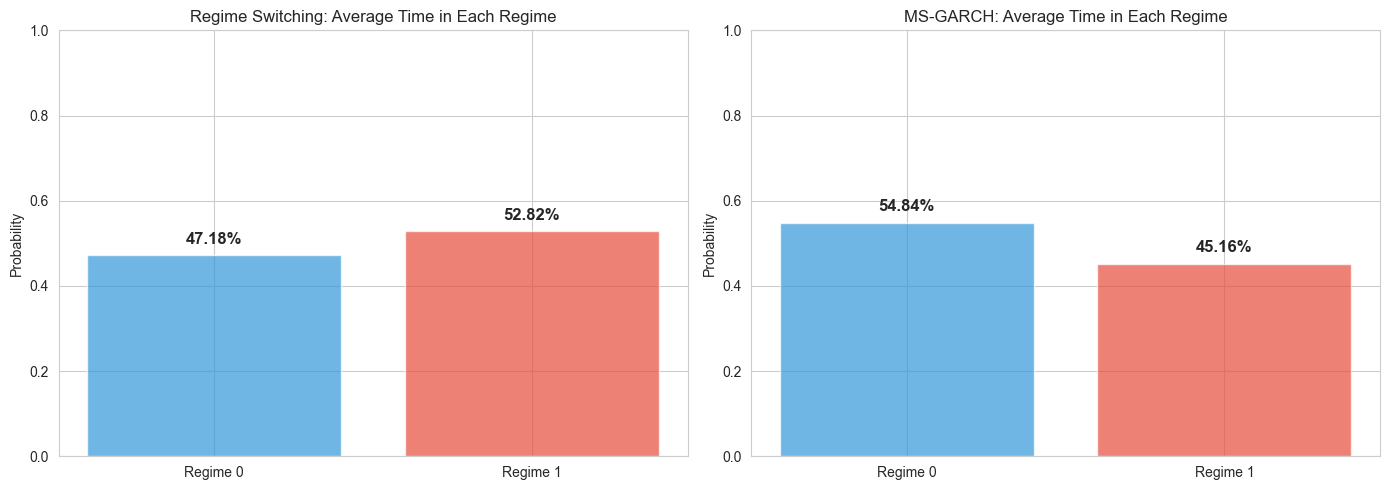

In [216]:
# Visualize regime frequencies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching
rs_regime_freq = rs_params[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[0].bar(['Regime 0', 'Regime 1'], rs_regime_freq, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Average Time in Each Regime')
axes[0].set_ylim([0, 1])
for i, v in enumerate(rs_regime_freq):
    axes[0].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# MS-GARCH
ms_regime_freq = ms_garch[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[1].bar(['Regime 0', 'Regime 1'], ms_regime_freq, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Probability')
axes[1].set_title('MS-GARCH: Average Time in Each Regime')
axes[1].set_ylim([0, 1])
for i, v in enumerate(ms_regime_freq):
    axes[1].text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

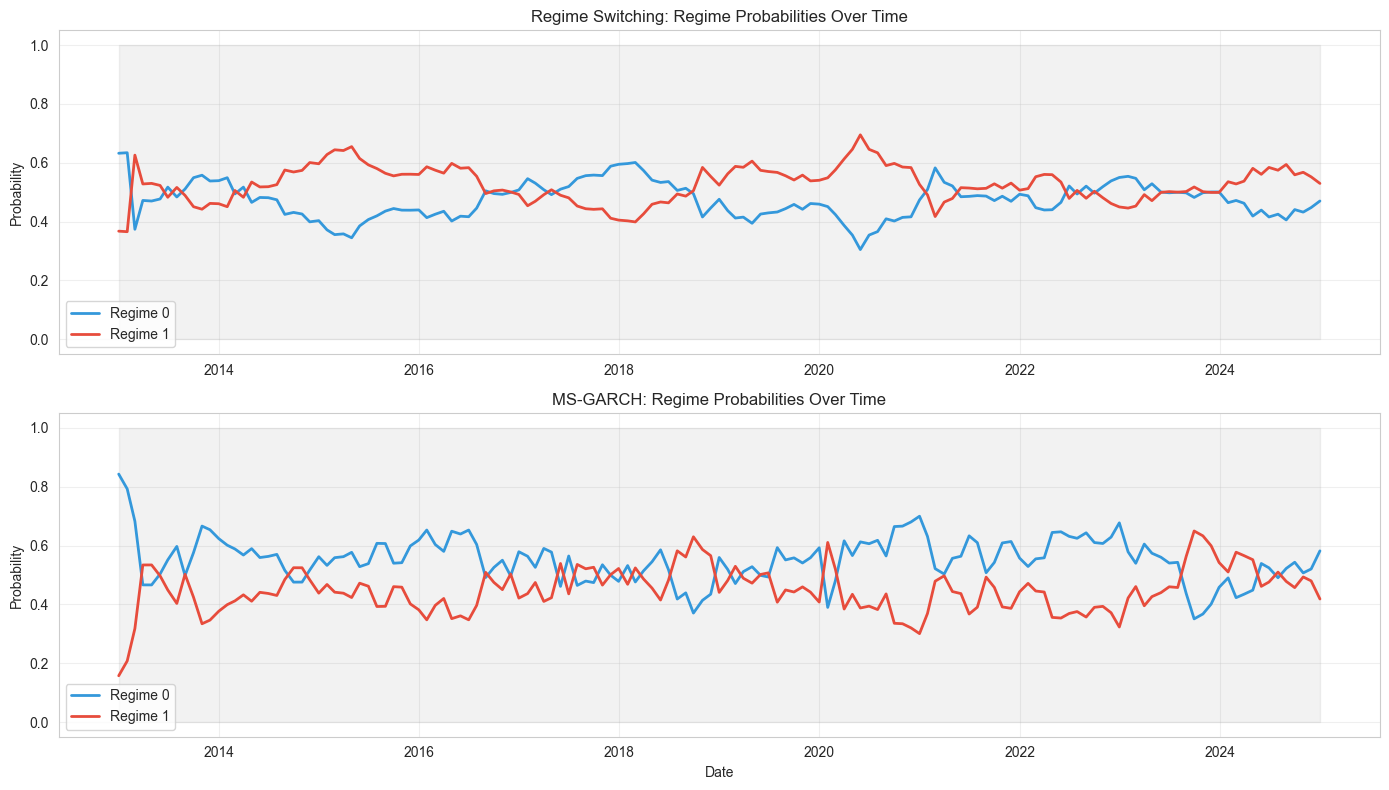

In [217]:
# Distribution of regime frequencies across time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Regime Switching over time
rs_time = rs_params.groupby('date')[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[0].plot(rs_time.index, rs_time['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[0].plot(rs_time.index, rs_time['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[0].fill_between(rs_time.index, 0, 1, alpha=0.1, color='gray')
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Regime Probabilities Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH over time
ms_time = ms_garch.groupby('date')[['steady_state_regime_0', 'steady_state_regime_1']].mean()
axes[1].plot(ms_time.index, ms_time['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[1].plot(ms_time.index, ms_time['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[1].fill_between(ms_time.index, 0, 1, alpha=0.1, color='gray')
axes[1].set_ylabel('Probability')
axes[1].set_xlabel('Date')
axes[1].set_title('MS-GARCH: Regime Probabilities Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Regime Duration Analysis

Expected duration in regime i: 1 / (1 - p_ii)

In [218]:
# Calculate expected durations
rs_params['duration_regime_0'] = 1 / (1 - rs_params['transition_prob_00'])
rs_params['duration_regime_1'] = 1 / (1 - rs_params['transition_prob_11'])

ms_garch['duration_regime_0'] = 1 / (1 - ms_garch['p00'])
ms_garch['duration_regime_1'] = 1 / (1 - ms_garch['p11'])

print('Regime Switching - Expected Duration (in periods):')
print(f'Regime 0: {rs_params["duration_regime_0"].mean():.2f} ± {rs_params["duration_regime_0"].std():.2f}')
print(f'Regime 1: {rs_params["duration_regime_1"].mean():.2f} ± {rs_params["duration_regime_1"].std():.2f}')

print('\nMS-GARCH - Expected Duration (in periods):')
print(f'Regime 0: {ms_garch["duration_regime_0"].mean():.2f} ± {ms_garch["duration_regime_0"].std():.2f}')
print(f'Regime 1: {ms_garch["duration_regime_1"].mean():.2f} ± {ms_garch["duration_regime_1"].std():.2f}')

Regime Switching - Expected Duration (in periods):
Regime 0: 58.98 ± 164.56
Regime 1: 125.25 ± 278.06

MS-GARCH - Expected Duration (in periods):
Regime 0: 39.74 ± 59.16
Regime 1: 32.06 ± 52.95


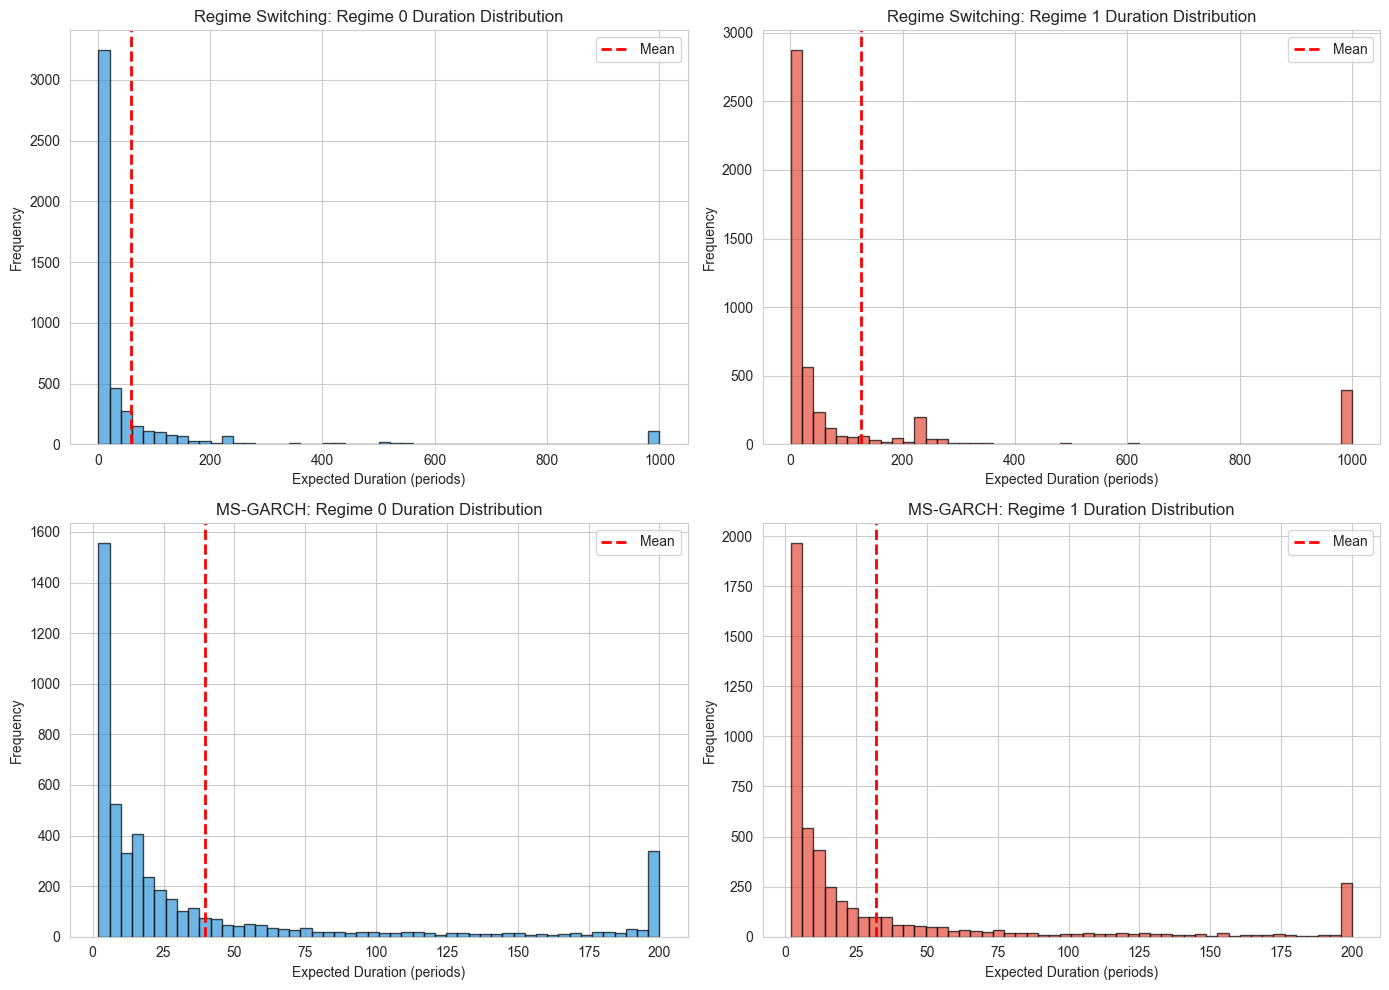


Note: Durations capped at 1000 periods for visualization
Infinite/extreme durations filtered:
  RS Regime 0: 0
  RS Regime 1: 0
  MS-GARCH Regime 0: 0
  MS-GARCH Regime 1: 0


In [219]:
# Visualize duration distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Filter out infinite values and cap durations for better visualization
def filter_duration(series, max_duration=1000):
    """Filter out infinite values and cap at max_duration for visualization"""
    return series.replace([np.inf, -np.inf], np.nan).clip(upper=max_duration)

# Regime Switching - Regime 0
rs_dur_0_filtered = filter_duration(rs_params['duration_regime_0'])
axes[0, 0].hist(rs_dur_0_filtered.dropna(), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(rs_dur_0_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Expected Duration (periods)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Regime Switching: Regime 0 Duration Distribution')
axes[0, 0].legend()

# Regime Switching - Regime 1
rs_dur_1_filtered = filter_duration(rs_params['duration_regime_1'])
axes[0, 1].hist(rs_dur_1_filtered.dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(rs_dur_1_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_xlabel('Expected Duration (periods)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Regime Switching: Regime 1 Duration Distribution')
axes[0, 1].legend()

# MS-GARCH - Regime 0
ms_dur_0_filtered = filter_duration(ms_garch['duration_regime_0'])
axes[1, 0].hist(ms_dur_0_filtered.dropna(), bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(ms_dur_0_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Expected Duration (periods)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('MS-GARCH: Regime 0 Duration Distribution')
axes[1, 0].legend()

# MS-GARCH - Regime 1
ms_dur_1_filtered = filter_duration(ms_garch['duration_regime_1'])
axes[1, 1].hist(ms_dur_1_filtered.dropna(), bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(ms_dur_1_filtered.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].set_xlabel('Expected Duration (periods)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('MS-GARCH: Regime 1 Duration Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print info about filtered values
print(f"\nNote: Durations capped at 1000 periods for visualization")
print(f"Infinite/extreme durations filtered:")
print(f"  RS Regime 0: {rs_params['duration_regime_0'].isna().sum() + (rs_params['duration_regime_0'] > 1000).sum()}")
print(f"  RS Regime 1: {rs_params['duration_regime_1'].isna().sum() + (rs_params['duration_regime_1'] > 1000).sum()}")
print(f"  MS-GARCH Regime 0: {ms_garch['duration_regime_0'].isna().sum() + (ms_garch['duration_regime_0'] > 1000).sum()}")
print(f"  MS-GARCH Regime 1: {ms_garch['duration_regime_1'].isna().sum() + (ms_garch['duration_regime_1'] > 1000).sum()}")

## 5. Parameter Comparison Between Regimes

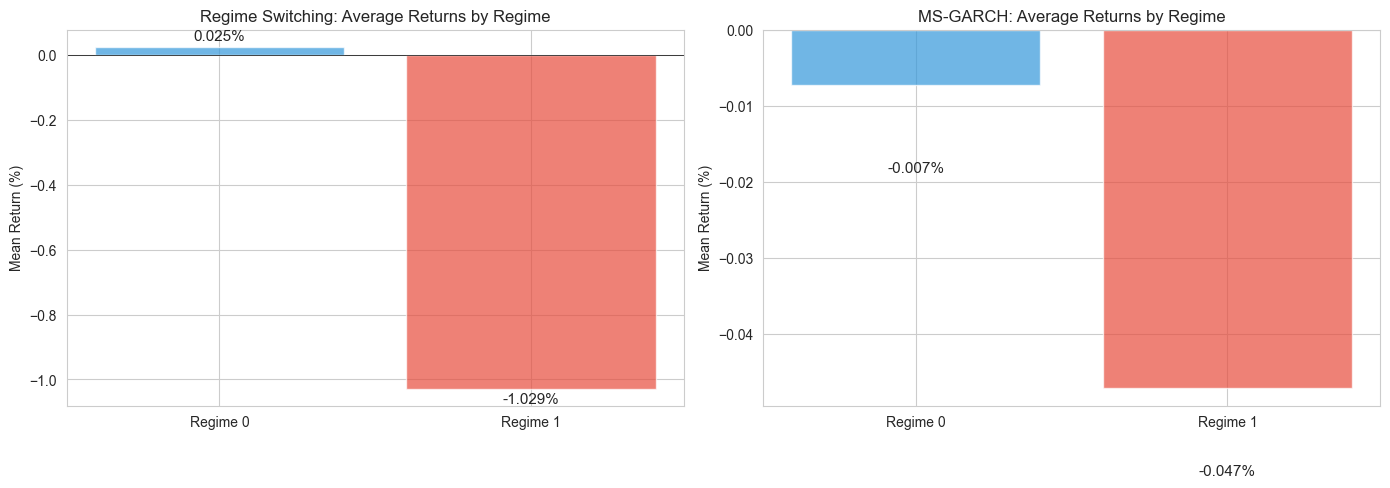

In [220]:
# Compare mean returns between regimes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching
rs_means = rs_params[['regime_0_mean', 'regime_1_mean']].mean() * 100  # Convert to percentage
axes[0].bar(['Regime 0', 'Regime 1'], rs_means, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Mean Return (%)')
axes[0].set_title('Regime Switching: Average Returns by Regime')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(rs_means):
    axes[0].text(i, v + (0.01 if v > 0 else -0.01), f'{v:.3f}%', ha='center', va='bottom' if v > 0 else 'top', fontsize=11)

# MS-GARCH
ms_means = ms_garch[['mu_0', 'mu_1']].mean() * 100
axes[1].bar(['Regime 0', 'Regime 1'], ms_means, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Mean Return (%)')
axes[1].set_title('MS-GARCH: Average Returns by Regime')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(ms_means):
    axes[1].text(i, v + (0.01 if v > 0 else -0.01), f'{v:.3f}%', ha='center', va='bottom' if v > 0 else 'top', fontsize=11)

plt.tight_layout()
plt.show()

In [221]:
# Detailed parameter comparison table
print('='*80)
print('REGIME SWITCHING MODEL - PARAMETER COMPARISON')
print('='*80)
comparison_rs = pd.DataFrame({
    'Parameter': ['Mean Return', 'Volatility', 'Degrees of Freedom (nu)'],
    'Regime 0': [
        f"{rs_params['regime_0_mean'].mean()*100:.4f}%",
        f"{rs_params['regime_0_vol'].mean()*100:.4f}%",
        f"{rs_params['regime_0_nu'].mean():.2f}"
    ],
    'Regime 1': [
        f"{rs_params['regime_1_mean'].mean()*100:.4f}%",
        f"{rs_params['regime_1_vol'].mean()*100:.4f}%",
        f"{rs_params['regime_1_nu'].mean():.2f}"
    ],
    'Difference': [
        f"{(rs_params['regime_1_mean'].mean() - rs_params['regime_0_mean'].mean())*100:.4f}%",
        f"{(rs_params['regime_1_vol'].mean() - rs_params['regime_0_vol'].mean())*100:.4f}%",
        f"{rs_params['regime_1_nu'].mean() - rs_params['regime_0_nu'].mean():.2f}"
    ]
})
display(comparison_rs)

print('\n' + '='*80)
print('MS-GARCH MODEL - PARAMETER COMPARISON')
print('='*80)
comparison_ms = pd.DataFrame({
    'Parameter': ['Mean Return', 'Degrees of Freedom (nu)', 'Omega', 'Alpha', 'Beta'],
    'Regime 0': [
        f"{ms_garch['mu_0'].mean()*100:.4f}%",
        f"{ms_garch['nu_0'].mean():.2f}",
        f"{ms_garch['omega_0'].mean():.6f}",
        f"{ms_garch['alpha_0'].mean():.6f}",
        f"{ms_garch['beta_0'].mean():.6f}"
    ],
    'Regime 1': [
        f"{ms_garch['mu_1'].mean()*100:.4f}%",
        f"{ms_garch['nu_1'].mean():.2f}",
        f"{ms_garch['omega_1'].mean():.6f}",
        f"{ms_garch['alpha_1'].mean():.6f}",
        f"{ms_garch['beta_1'].mean():.6f}"
    ],
    'Ratio (R1/R0)': [
        f"{ms_garch['mu_1'].mean() / ms_garch['mu_0'].mean() if ms_garch['mu_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['nu_1'].mean() / ms_garch['nu_0'].mean():.2f}",
        f"{ms_garch['omega_1'].mean() / ms_garch['omega_0'].mean() if ms_garch['omega_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['alpha_1'].mean() / ms_garch['alpha_0'].mean() if ms_garch['alpha_0'].mean() != 0 else np.nan:.2f}",
        f"{ms_garch['beta_1'].mean() / ms_garch['beta_0'].mean():.2f}"
    ]
})
display(comparison_ms)

REGIME SWITCHING MODEL - PARAMETER COMPARISON


,Parameter,Regime 0,Regime 1,Difference
0,Mean Return,0.0254%,-1.0289%,-1.0543%
1,Volatility,0.6387%,1.7628%,1.1241%
2,Degrees of Freedom (nu),53.12,27.02,-26.10



MS-GARCH MODEL - PARAMETER COMPARISON


,Parameter,Regime 0,Regime 1,Ratio (R1/R0)
0,Mean Return,-0.0073%,-0.0471%,6.48
1,Degrees of Freedom (nu),22.23,6.07,0.27
2,Omega,0.000021,0.000122,5.79
3,Alpha,0.058166,0.113360,1.95
4,Beta,0.768652,0.736649,0.96


## 6. Volatility Analysis by Regime

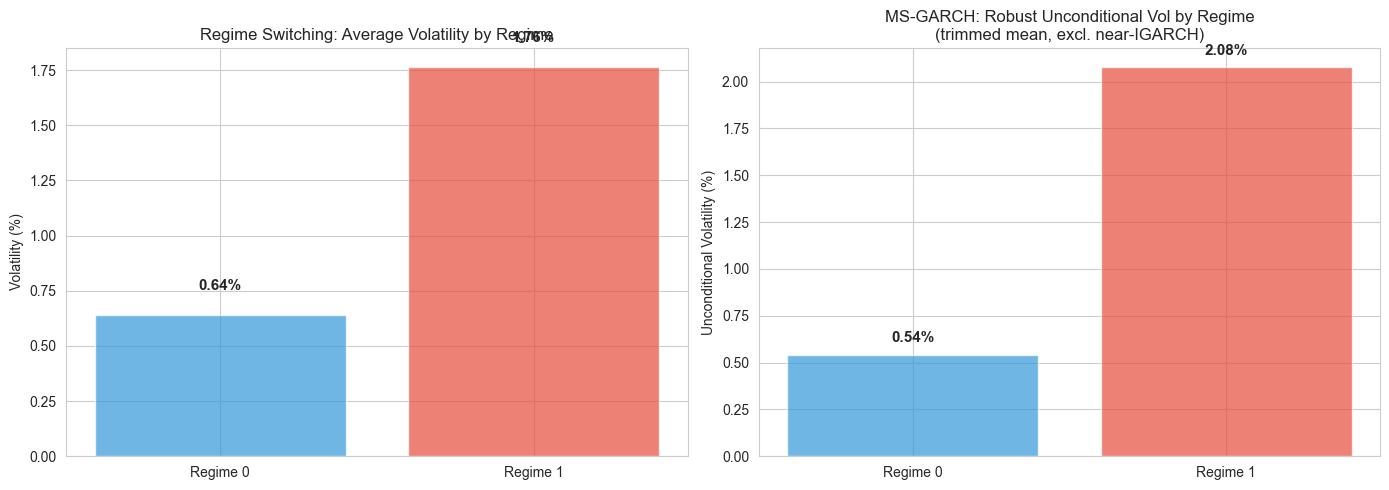

Regime Switching:  Vol Ratio (R1/R0) = 2.76x
MS-GARCH (naive):  Vol Ratio (R1/R0) = 4.17x  ⚠️ inflated by near-IGARCH rows
MS-GARCH (robust): Vol Ratio (R1/R0) = 3.82x

Regime 0: 0 of 4842 rows (0.0%) have persistence ≥ 0.999 → uncond vol set to NaN
Regime 1: 0 of 4842 rows (0.0%) have persistence ≥ 0.999 → uncond vol set to NaN


In [222]:
# Volatility comparison — ROBUST unconditional vol for MS-GARCH
# 
# The naive formula  sqrt(omega / (1 - alpha - beta))  explodes when
# persistence → 1  (denominator → 0).  In the current estimates:
#   • 22.8% of Regime-1 rows have persistence > 0.99 (near-IGARCH)
#   • 50% of alpha values are < 0.01  (bimodal: old Hamilton filter artefact)
#
# FIX:  (a) filter rows where persistence >= 0.999  (no valid unconditional vol)
#        (b) use trimmed mean (drop top/bottom 5%) for a robust central estimate

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regime Switching — these are stored directly, no inflation issue
rs_vols = rs_params[['regime_0_vol', 'regime_1_vol']].mean() * 100
axes[0].bar(['Regime 0', 'Regime 1'], rs_vols, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Volatility (%)')
axes[0].set_title('Regime Switching: Average Volatility by Regime')
for i, v in enumerate(rs_vols):
    axes[0].text(i, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# MS-GARCH — Robust unconditional volatility
# Step 1: compute raw persistence and uncond_vol
ms_garch['persist_0'] = ms_garch['alpha_0'] + ms_garch['beta_0']
ms_garch['persist_1'] = ms_garch['alpha_1'] + ms_garch['beta_1']

# Step 2: compute unconditional vol, but mark near-IGARCH as NaN
for r in [0, 1]:
    p_col = f'persist_{r}'
    denom = 1 - ms_garch[p_col]
    # Where persistence >= 0.999, uncond vol is not well-defined
    denom_safe = denom.where(denom > 0.001, other=np.nan)
    ms_garch[f'uncond_vol_{r}'] = np.sqrt(ms_garch[f'omega_{r}'] / denom_safe)

# Step 3: trimmed mean (drop top/bottom 5%) for robust summary
def trimmed_mean(s, pct=0.05):
    """Mean after dropping the top and bottom pct fraction."""
    s = s.dropna()
    lo, hi = s.quantile(pct), s.quantile(1 - pct)
    return s[(s >= lo) & (s <= hi)].mean()

ms_vols_robust = pd.Series({
    'uncond_vol_0': trimmed_mean(ms_garch['uncond_vol_0']) * 100,
    'uncond_vol_1': trimmed_mean(ms_garch['uncond_vol_1']) * 100,
})

axes[1].bar(['Regime 0', 'Regime 1'], ms_vols_robust, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Unconditional Volatility (%)')
axes[1].set_title('MS-GARCH: Robust Unconditional Vol by Regime\n(trimmed mean, excl. near-IGARCH)')
for i, v in enumerate(ms_vols_robust):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print both naive and robust
ms_vols_naive = ms_garch[['uncond_vol_0', 'uncond_vol_1']].mean() * 100
print(f"Regime Switching:  Vol Ratio (R1/R0) = {rs_vols['regime_1_vol'] / rs_vols['regime_0_vol']:.2f}x")
print(f"MS-GARCH (naive):  Vol Ratio (R1/R0) = {ms_vols_naive['uncond_vol_1'] / ms_vols_naive['uncond_vol_0']:.2f}x  ⚠️ inflated by near-IGARCH rows")
print(f"MS-GARCH (robust): Vol Ratio (R1/R0) = {ms_vols_robust['uncond_vol_1'] / ms_vols_robust['uncond_vol_0']:.2f}x")
print()
# Diagnostic breakdown
n_total = len(ms_garch)
for r in [0, 1]:
    n_igarch = (ms_garch[f'persist_{r}'] >= 0.999).sum()
    n_nan = ms_garch[f'uncond_vol_{r}'].isna().sum()
    print(f"Regime {r}: {n_igarch} of {n_total} rows ({n_igarch/n_total*100:.1f}%) "
          f"have persistence ≥ 0.999 → uncond vol set to NaN")

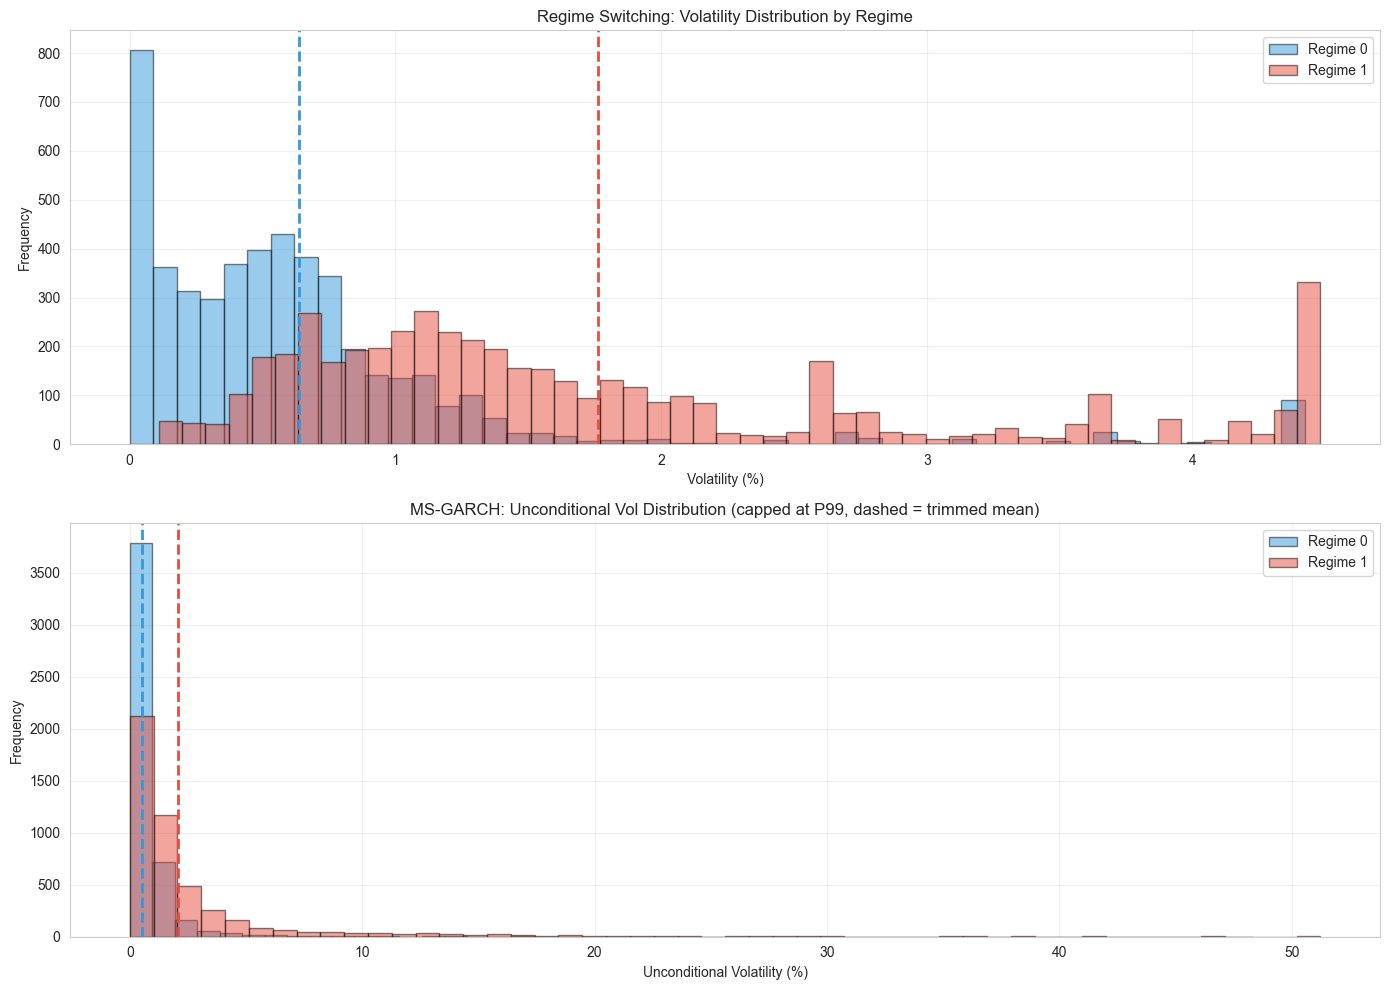

In [223]:
# Volatility distributions (NaN-safe — drops near-IGARCH rows)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Regime Switching
axes[0].hist(rs_params['regime_0_vol']*100, bins=50, alpha=0.5, label='Regime 0', color='#3498db', edgecolor='black')
axes[0].hist(rs_params['regime_1_vol']*100, bins=50, alpha=0.5, label='Regime 1', color='#e74c3c', edgecolor='black')
axes[0].axvline(rs_params['regime_0_vol'].mean()*100, color='#3498db', linestyle='--', linewidth=2)
axes[0].axvline(rs_params['regime_1_vol'].mean()*100, color='#e74c3c', linestyle='--', linewidth=2)
axes[0].set_xlabel('Volatility (%)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Regime Switching: Volatility Distribution by Regime')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH — filter out NaN and extreme outliers (cap at P99 for visualisation)
v0 = ms_garch['uncond_vol_0'].dropna() * 100
v1 = ms_garch['uncond_vol_1'].dropna() * 100
cap = max(v0.quantile(0.99), v1.quantile(0.99))  # visual cap
axes[1].hist(v0[v0 <= cap], bins=50, alpha=0.5, label='Regime 0', color='#3498db', edgecolor='black')
axes[1].hist(v1[v1 <= cap], bins=50, alpha=0.5, label='Regime 1', color='#e74c3c', edgecolor='black')
axes[1].axvline(trimmed_mean(ms_garch['uncond_vol_0'])*100, color='#3498db', linestyle='--', linewidth=2)
axes[1].axvline(trimmed_mean(ms_garch['uncond_vol_1'])*100, color='#e74c3c', linestyle='--', linewidth=2)
axes[1].set_xlabel('Unconditional Volatility (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('MS-GARCH: Unconditional Vol Distribution (capped at P99, dashed = trimmed mean)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Rows with unconditional vol > 10%: 394 / 4842
Unique firms involved: 33

Per-firm summary of extreme unconditional volatilities:


,n_extreme,date_min,date_max,max_vol_0,max_vol_1,median_p0,median_p1
gvkey,,,,,,,
103487,30,2013-05-31,2023-08-31,22.392913,158.113883,0.832255,0.998000
220940,4,2017-03-31,2022-02-28,0.514884,158.113883,0.933347,0.998000
15617,21,2013-06-28,2023-07-31,27.654388,158.113883,0.964631,0.798610
132740,13,2014-05-30,2024-05-31,2.164147,158.113883,0.717574,0.998000
16348,10,2013-04-30,2021-07-30,2.429378,158.113883,0.613934,0.998000
241456,11,2013-09-30,2022-08-31,10.179077,158.113883,0.900308,0.998000
220833,4,2014-12-31,2022-04-29,0.628122,158.113883,0.698733,0.998000
23671,20,2013-09-30,2024-11-29,3.869618,97.752851,0.712517,0.998000
15549,42,2013-03-29,2024-07-31,110.362648,90.392003,0.800036,0.874725



Top 20 most extreme individual (firm × date) observations:


,gvkey,date,omega_0,alpha_0,beta_0,persistence_0,uncond_vol_0,omega_1,alpha_1,beta_1,persistence_1,uncond_vol_1
3532,103487,2022-12-30,5.535992e-05,0.010001,0.689657,0.699658,1.357655,0.005000,0.016853,0.981147,0.998000,158.113883
536,15617,2022-04-29,2.411877e-06,0.500000,0.420347,0.920347,0.550271,0.005000,0.320942,0.677058,0.998000,158.113883
863,16348,2014-02-28,1.883309e-06,0.384428,0.605572,0.990000,1.372337,0.005000,0.500000,0.498000,0.998000,158.113883
948,16348,2021-03-31,1.851397e-04,0.095057,0.504943,0.600000,2.151393,0.005000,0.055945,0.942055,0.998000,158.113883
3677,132740,2022-12-30,1.078469e-04,0.010001,0.728268,0.738269,2.029906,0.005000,0.397355,0.600645,0.998000,158.113883
4093,220940,2022-02-28,5.302118e-08,0.010000,0.988000,0.998000,0.514884,0.005000,0.500000,0.498000,0.998000,158.113883
4563,241456,2013-09-30,4.730943e-07,0.010000,0.985129,0.995129,0.985531,0.005000,0.500000,0.498000,0.998000,158.113883
4564,241456,2013-10-31,3.760444e-07,0.010000,0.988000,0.998000,1.371212,0.005000,0.499999,0.498001,0.998000,158.113883
3894,220833,2017-06-30,6.309202e-06,0.010000,0.686983,0.696983,0.456303,0.005000,0.500000,0.498000,0.998000,158.113883
537,15617,2022-05-31,3.638673e-06,0.499999,0.406986,0.906985,0.625454,0.004921,0.308099,0.689901,0.998000,156.858188


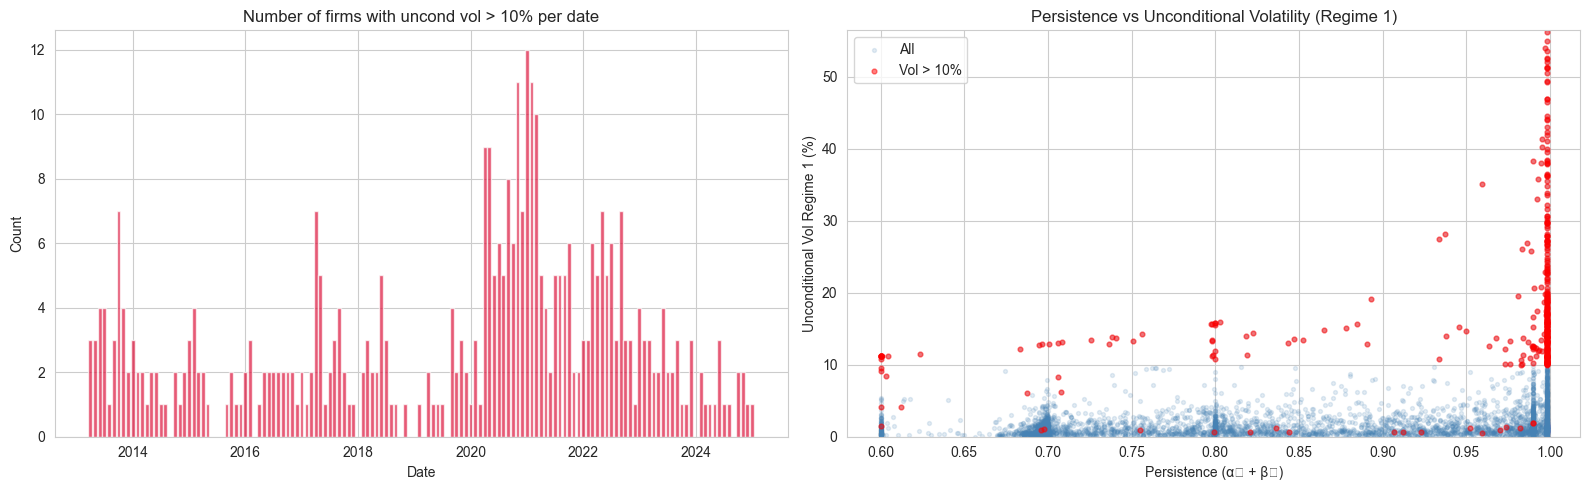

In [247]:

# ── Investigate extreme MS-GARCH unconditional volatilities ──────────────────

# Compute unconditional vol for each regime: sqrt(omega / (1 - alpha - beta))
ms_garch['persistence_0'] = ms_garch['alpha_0'] + ms_garch['beta_0']
ms_garch['persistence_1'] = ms_garch['alpha_1'] + ms_garch['beta_1']
ms_garch['uncond_var_0']  = ms_garch['omega_0'] / (1 - ms_garch['persistence_0'])
ms_garch['uncond_var_1']  = ms_garch['omega_1'] / (1 - ms_garch['persistence_1'])
ms_garch['uncond_vol_0']  = np.sqrt(ms_garch['uncond_var_0'].clip(lower=0)) * 100  # in %
ms_garch['uncond_vol_1']  = np.sqrt(ms_garch['uncond_var_1'].clip(lower=0)) * 100  # in %

# ── Flag extreme rows (unconditional vol > 10% in either regime) ─────────────
THRESHOLD = 10  # percent
extreme = ms_garch[
    (ms_garch['uncond_vol_0'] > THRESHOLD) | (ms_garch['uncond_vol_1'] > THRESHOLD)
].copy()

print(f"Rows with unconditional vol > {THRESHOLD}%: {len(extreme)} / {len(ms_garch)}")
print(f"Unique firms involved: {extreme['gvkey'].nunique()}\n")

# ── Per-firm summary of extreme observations ─────────────────────────────────
extreme_summary = (
    extreme
    .groupby('gvkey')
    .agg(
        n_extreme   = ('date', 'size'),
        date_min    = ('date', 'min'),
        date_max    = ('date', 'max'),
        max_vol_0   = ('uncond_vol_0', 'max'),
        max_vol_1   = ('uncond_vol_1', 'max'),
        median_p0   = ('persistence_0', 'median'),
        median_p1   = ('persistence_1', 'median'),
    )
    .sort_values('max_vol_1', ascending=False)
)
print("Per-firm summary of extreme unconditional volatilities:")
display(extreme_summary)

# ── Show the top 20 most extreme individual observations ─────────────────────
print("\nTop 20 most extreme individual (firm × date) observations:")
top_extreme = (
    extreme
    .assign(max_uncond_vol=lambda d: d[['uncond_vol_0','uncond_vol_1']].max(axis=1))
    .nlargest(20, 'max_uncond_vol')
    [['gvkey','date','omega_0','alpha_0','beta_0','persistence_0','uncond_vol_0',
      'omega_1','alpha_1','beta_1','persistence_1','uncond_vol_1']]
)
display(top_extreme)

# ── Time-series: how many extreme observations per date? ─────────────────────
extreme_by_date = extreme.groupby('date').size()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(extreme_by_date.index, extreme_by_date.values, width=25, color='crimson', alpha=0.7)
axes[0].set_title(f'Number of firms with uncond vol > {THRESHOLD}% per date')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Count')

# Scatter: persistence vs unconditional vol (regime 1)
axes[1].scatter(ms_garch['persistence_1'], ms_garch['uncond_vol_1'],
                alpha=0.15, s=8, color='steelblue', label='All')
axes[1].scatter(extreme['persistence_1'], extreme['uncond_vol_1'],
                alpha=0.5, s=12, color='red', label=f'Vol > {THRESHOLD}%')
axes[1].set_xlabel('Persistence (α₁ + β₁)')
axes[1].set_ylabel('Unconditional Vol Regime 1 (%)')
axes[1].set_title('Persistence vs Unconditional Volatility (Regime 1)')
axes[1].legend()
axes[1].set_ylim(0, ms_garch['uncond_vol_1'].quantile(0.99)*1.1)

plt.tight_layout()
plt.show()


Effect of different persistence caps on MS-GARCH unconditional volatility:



,persistence_cap,rows_kept,rows_excluded,pct_kept,max_uncond_vol_R0 (%),max_uncond_vol_R1 (%),p99_uncond_vol_R1 (%),p95_uncond_vol_R1 (%),median_uncond_vol_R1 (%)
0,0.999,4842,0,100.0%,110.4,158.1,51.3,13.9,1.22
1,0.998,4081,761,84.3%,110.4,158.1,27.6,9.0,1.13
2,0.997,3582,1260,74.0%,52.1,88.7,14.3,6.3,1.07
3,0.995,3509,1333,72.5%,45.3,88.7,13.8,6.1,1.07
4,0.993,3441,1401,71.1%,45.3,60.3,13.6,6.0,1.07
5,0.990,3238,1604,66.9%,27.7,60.3,13.3,5.8,1.06
6,0.985,2742,2100,56.6%,27.7,35.1,13.4,5.2,1.07
7,0.980,2538,2304,52.4%,27.7,35.1,13.3,5.2,1.10
8,0.975,2432,2410,50.2%,27.7,35.1,13.4,5.2,1.09
9,0.970,2359,2483,48.7%,10.0,35.1,13.3,5.0,1.08


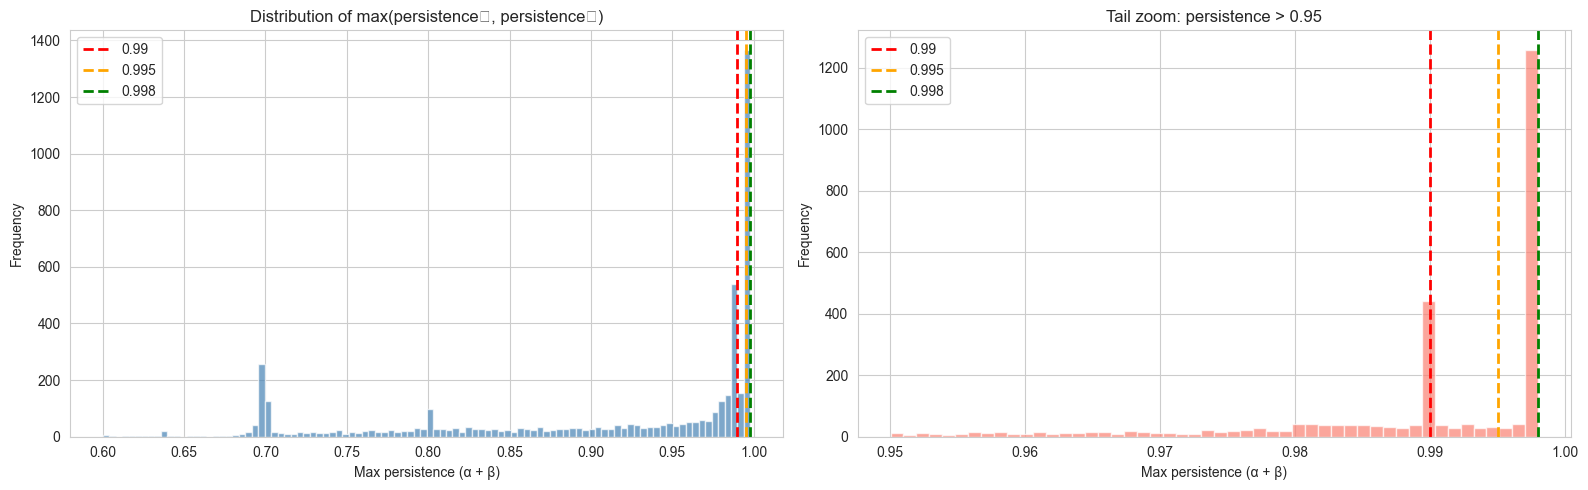

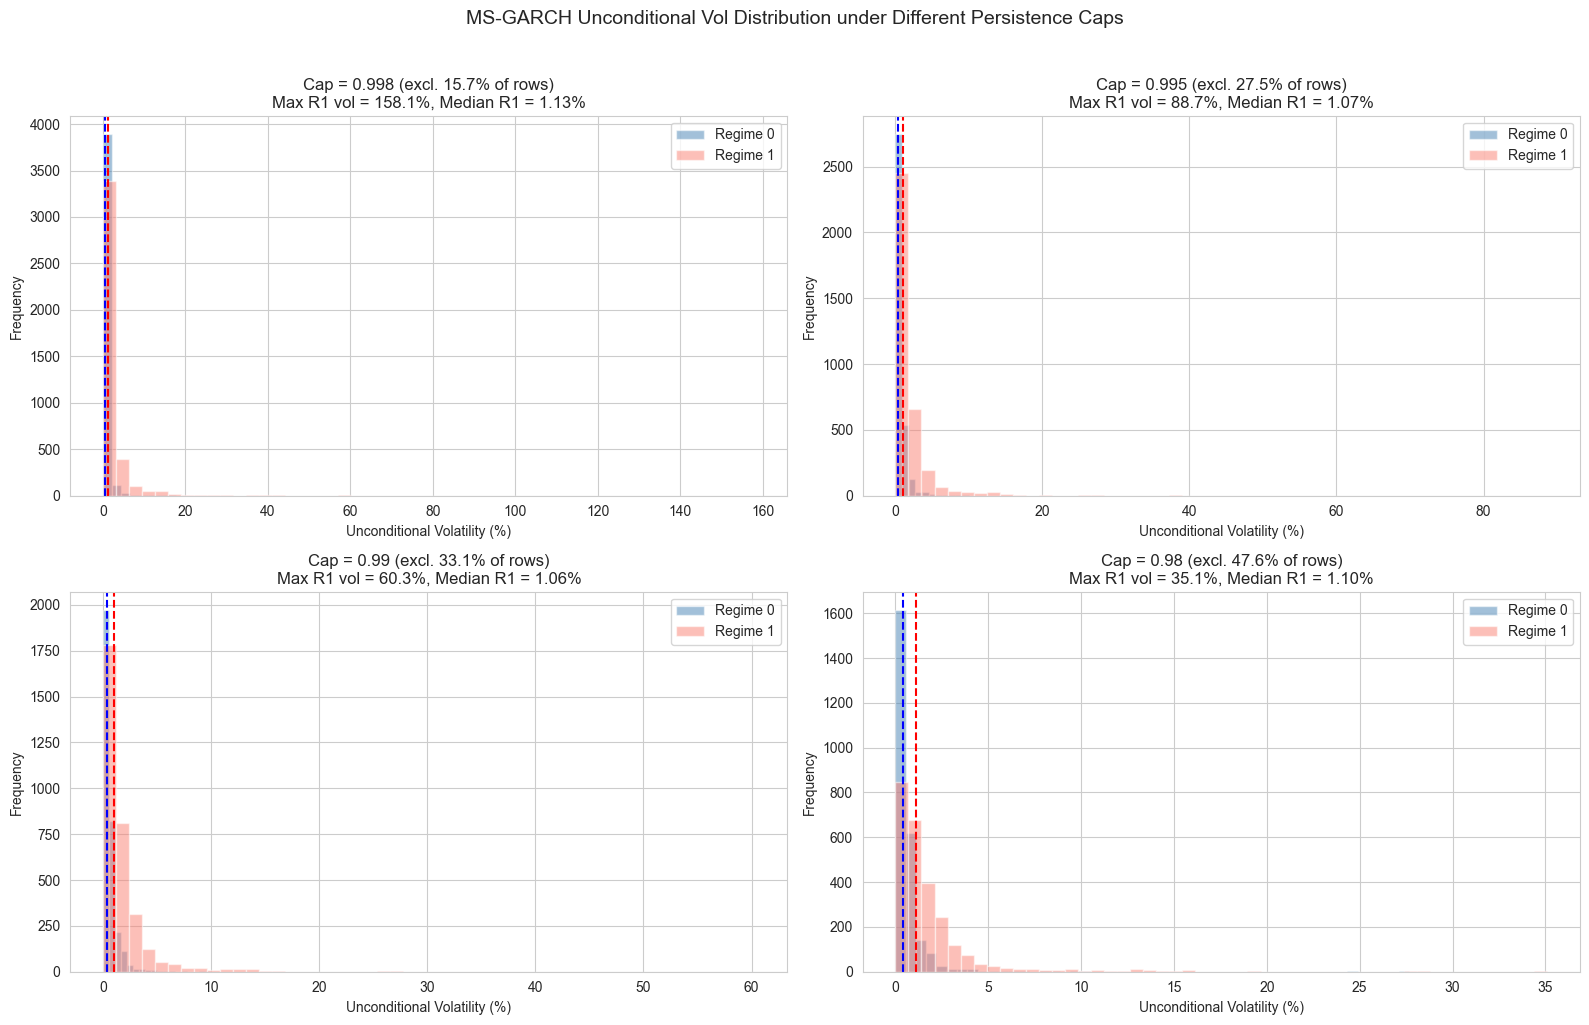

In [248]:

# ── Find the right persistence cap ──────────────────────────────────────────
# Test a range of persistence thresholds and see how many rows are excluded
# and what the resulting max unconditional vol looks like.

thresholds = [0.999, 0.998, 0.997, 0.995, 0.993, 0.99, 0.985, 0.98, 0.975, 0.97, 0.96, 0.95]

# Compute persistence for both regimes
p0 = ms_garch['alpha_0'] + ms_garch['beta_0']
p1 = ms_garch['alpha_1'] + ms_garch['beta_1']
max_p = np.maximum(p0, p1)

rows = []
for thr in thresholds:
    mask = max_p < thr
    kept = mask.sum()
    pct_kept = kept / len(ms_garch) * 100
    
    # Compute uncond vol for kept rows
    uv0 = np.sqrt((ms_garch.loc[mask, 'omega_0'] / (1 - p0[mask])).clip(lower=0)) * 100
    uv1 = np.sqrt((ms_garch.loc[mask, 'omega_1'] / (1 - p1[mask])).clip(lower=0)) * 100
    
    rows.append({
        'persistence_cap': thr,
        'rows_kept': kept,
        'rows_excluded': len(ms_garch) - kept,
        'pct_kept': f'{pct_kept:.1f}%',
        'max_uncond_vol_R0 (%)': f'{uv0.max():.1f}',
        'max_uncond_vol_R1 (%)': f'{uv1.max():.1f}',
        'p99_uncond_vol_R1 (%)': f'{uv1.quantile(0.99):.1f}',
        'p95_uncond_vol_R1 (%)': f'{uv1.quantile(0.95):.1f}',
        'median_uncond_vol_R1 (%)': f'{uv1.median():.2f}',
    })

cap_analysis = pd.DataFrame(rows)
print("Effect of different persistence caps on MS-GARCH unconditional volatility:\n")
display(cap_analysis)

# ── Visual: distribution of max persistence across all rows ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: histogram of max(persistence_0, persistence_1)
axes[0].hist(max_p, bins=100, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(0.99, color='red', ls='--', lw=2, label='0.99')
axes[0].axvline(0.995, color='orange', ls='--', lw=2, label='0.995')
axes[0].axvline(0.998, color='green', ls='--', lw=2, label='0.998')
axes[0].set_xlabel('Max persistence (α + β)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of max(persistence₀, persistence₁)')
axes[0].legend()

# Right: zoom into the high-persistence tail
tail = max_p[max_p > 0.95]
axes[1].hist(tail, bins=50, color='salmon', alpha=0.7, edgecolor='white')
axes[1].axvline(0.99, color='red', ls='--', lw=2, label='0.99')
axes[1].axvline(0.995, color='orange', ls='--', lw=2, label='0.995')
axes[1].axvline(0.998, color='green', ls='--', lw=2, label='0.998')
axes[1].set_xlabel('Max persistence (α + β)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Tail zoom: persistence > 0.95')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Show resulting vol distribution for a few candidate caps ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
candidate_caps = [0.998, 0.995, 0.99, 0.98]

for ax, cap_val in zip(axes.flat, candidate_caps):
    mask = max_p < cap_val
    uv0 = np.sqrt((ms_garch.loc[mask, 'omega_0'] / (1 - p0[mask])).clip(lower=0)) * 100
    uv1 = np.sqrt((ms_garch.loc[mask, 'omega_1'] / (1 - p1[mask])).clip(lower=0)) * 100
    
    ax.hist(uv0, bins=50, alpha=0.5, color='steelblue', label='Regime 0')
    ax.hist(uv1, bins=50, alpha=0.5, color='salmon', label='Regime 1')
    ax.axvline(uv0.median(), color='blue', ls='--', lw=1.5)
    ax.axvline(uv1.median(), color='red', ls='--', lw=1.5)
    excluded_pct = (1 - mask.sum()/len(ms_garch)) * 100
    ax.set_title(f'Cap = {cap_val} (excl. {excluded_pct:.1f}% of rows)\n'
                 f'Max R1 vol = {uv1.max():.1f}%, Median R1 = {uv1.median():.2f}%')
    ax.set_xlabel('Unconditional Volatility (%)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('MS-GARCH Unconditional Vol Distribution under Different Persistence Caps', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 7. Transition Probability Analysis

In [224]:
# Analyze transition probabilities
print('='*80)
print('REGIME SWITCHING - TRANSITION PROBABILITIES')
print('='*80)
print(f"P(stay in Regime 0 | in Regime 0): {rs_params['transition_prob_00'].mean():.4f}")
print(f"P(switch to Regime 1 | in Regime 0): {rs_params['transition_prob_01'].mean():.4f}")
print(f"P(switch to Regime 0 | in Regime 1): {rs_params['transition_prob_10'].mean():.4f}")
print(f"P(stay in Regime 1 | in Regime 1): {rs_params['transition_prob_11'].mean():.4f}")

print('\n' + '='*80)
print('MS-GARCH - TRANSITION PROBABILITIES')
print('='*80)
print(f"P(stay in Regime 0 | in Regime 0): {ms_garch['p00'].mean():.4f}")
print(f"P(switch to Regime 1 | in Regime 0): {(1 - ms_garch['p00']).mean():.4f}")
print(f"P(switch to Regime 0 | in Regime 1): {(1 - ms_garch['p11']).mean():.4f}")
print(f"P(stay in Regime 1 | in Regime 1): {ms_garch['p11'].mean():.4f}")

REGIME SWITCHING - TRANSITION PROBABILITIES
P(stay in Regime 0 | in Regime 0): 0.6943
P(switch to Regime 1 | in Regime 0): 0.3057
P(switch to Regime 0 | in Regime 1): 0.2428
P(stay in Regime 1 | in Regime 1): 0.7572

MS-GARCH - TRANSITION PROBABILITIES
P(stay in Regime 0 | in Regime 0): 0.8390
P(switch to Regime 1 | in Regime 0): 0.1610
P(switch to Regime 0 | in Regime 1): 0.1909
P(stay in Regime 1 | in Regime 1): 0.8091


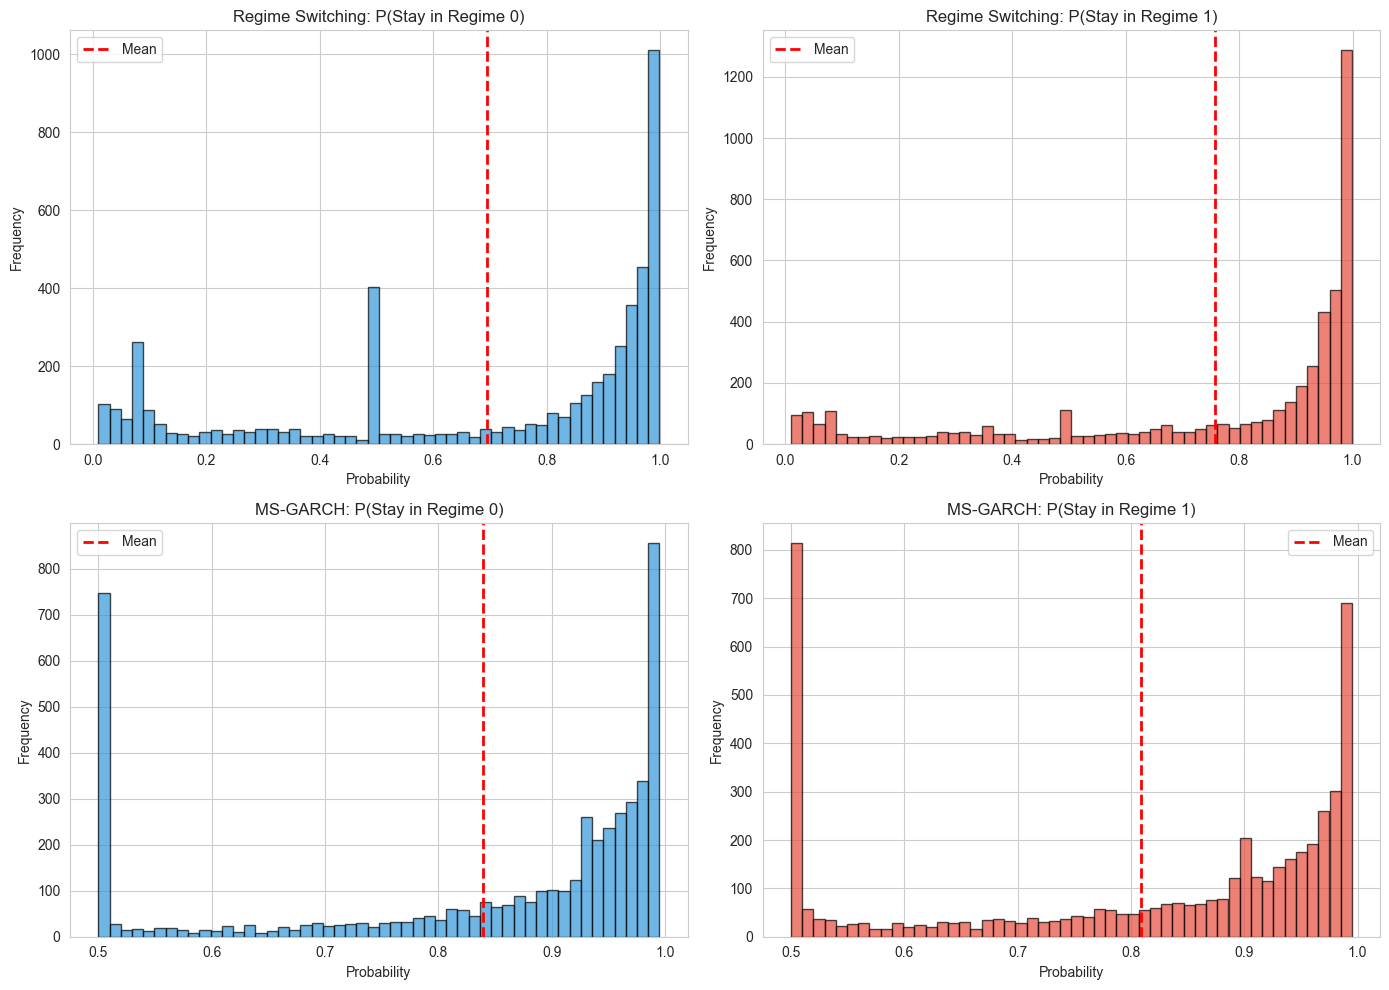

In [225]:
# Visualize transition probabilities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Regime Switching - Persistence
axes[0, 0].hist(rs_params['transition_prob_00'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(rs_params['transition_prob_00'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Probability')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Regime Switching: P(Stay in Regime 0)')
axes[0, 0].legend()

axes[0, 1].hist(rs_params['transition_prob_11'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(rs_params['transition_prob_11'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_xlabel('Probability')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Regime Switching: P(Stay in Regime 1)')
axes[0, 1].legend()

# MS-GARCH - Persistence
axes[1, 0].hist(ms_garch['p00'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(ms_garch['p00'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Probability')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('MS-GARCH: P(Stay in Regime 0)')
axes[1, 0].legend()

axes[1, 1].hist(ms_garch['p11'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(ms_garch['p11'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].set_xlabel('Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('MS-GARCH: P(Stay in Regime 1)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

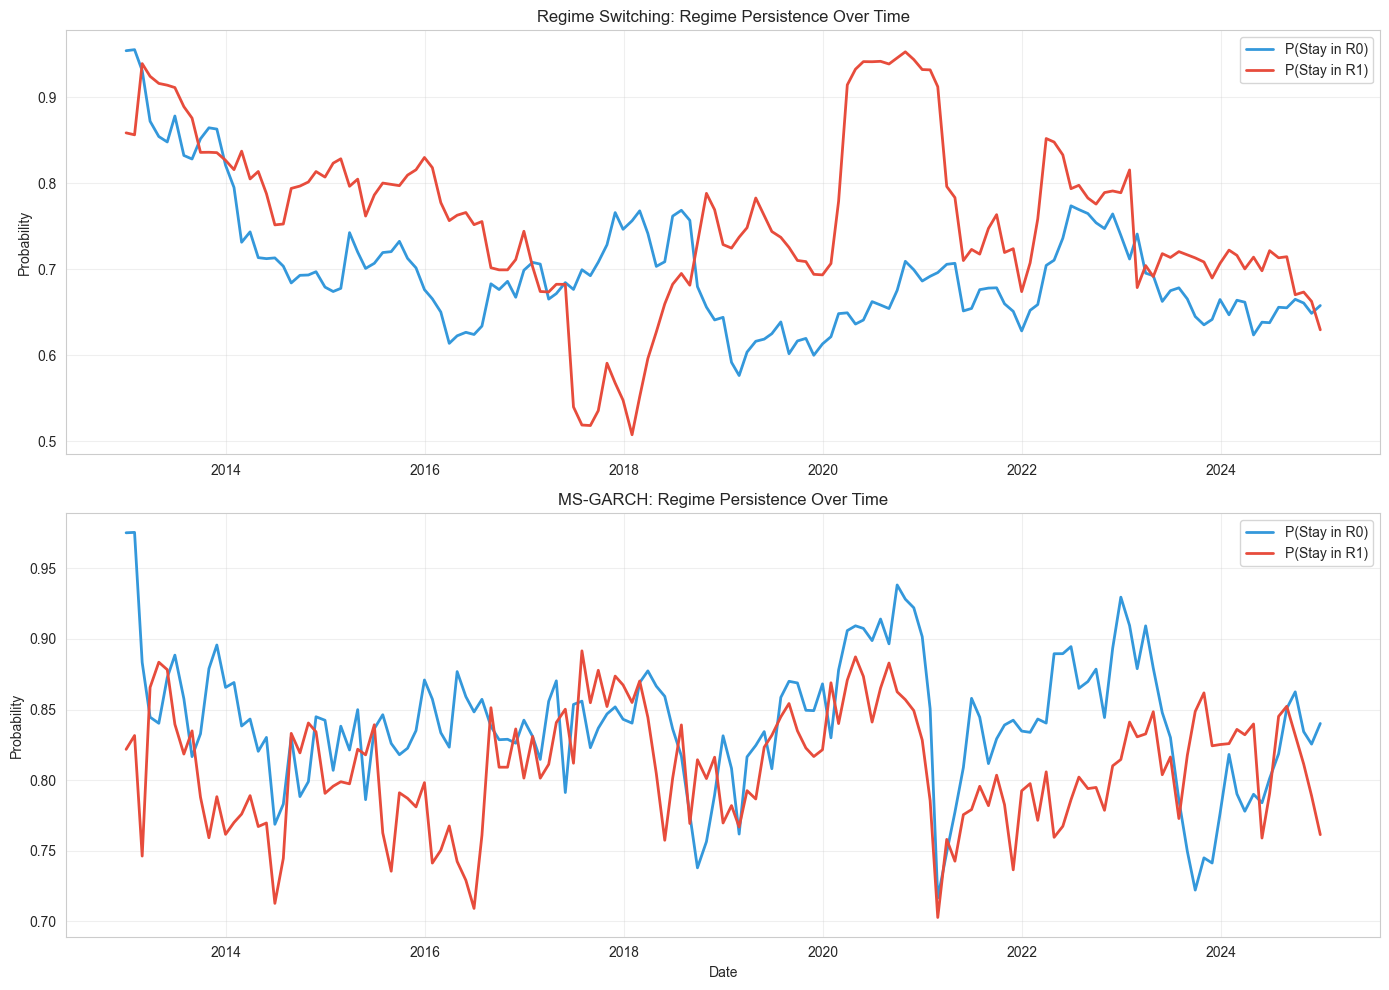

In [226]:
# Transition probabilities over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Regime Switching
rs_trans_time = rs_params.groupby('date')[['transition_prob_00', 'transition_prob_11']].mean()
axes[0].plot(rs_trans_time.index, rs_trans_time['transition_prob_00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[0].plot(rs_trans_time.index, rs_trans_time['transition_prob_11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[0].set_ylabel('Probability')
axes[0].set_title('Regime Switching: Regime Persistence Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MS-GARCH
ms_trans_time = ms_garch.groupby('date')[['p00', 'p11']].mean()
axes[1].plot(ms_trans_time.index, ms_trans_time['p00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[1].plot(ms_trans_time.index, ms_trans_time['p11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[1].set_ylabel('Probability')
axes[1].set_xlabel('Date')
axes[1].set_title('MS-GARCH: Regime Persistence Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Time Series Visualization of Regimes

Let's look at a specific company over time.

In [227]:
# Select a company to analyze
sample_gvkey = rs_params['gvkey'].iloc[0]
print(f"Analyzing company: {sample_gvkey}")

# Filter data for this company
rs_company = rs_params[rs_params['gvkey'] == sample_gvkey].sort_values('date')
ms_company = ms_garch[ms_garch['gvkey'] == sample_gvkey].sort_values('date')

Analyzing company: 14447


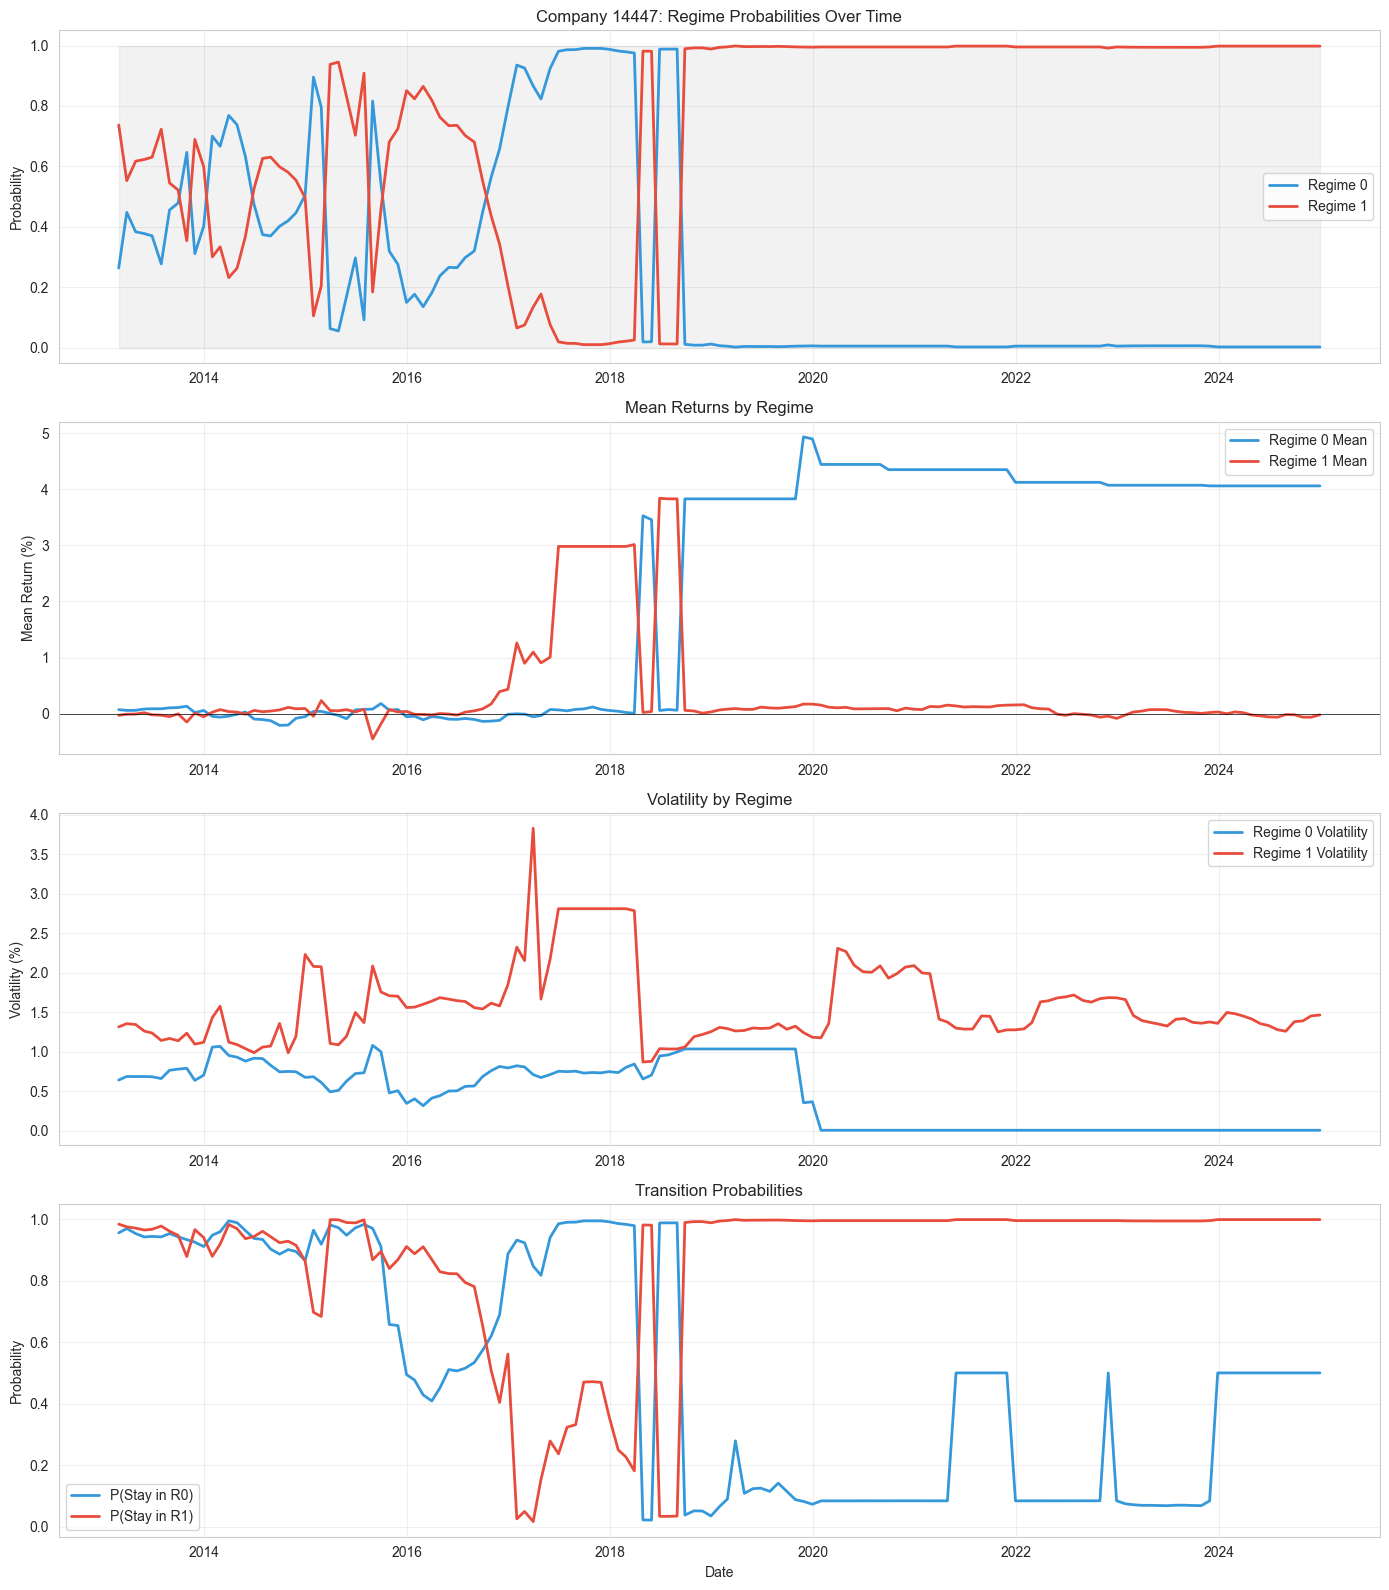

In [228]:
# Plot regime probabilities and parameters over time
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# Regime probabilities
axes[0].plot(rs_company['date'], rs_company['steady_state_regime_0'], label='Regime 0', color='#3498db', linewidth=2)
axes[0].plot(rs_company['date'], rs_company['steady_state_regime_1'], label='Regime 1', color='#e74c3c', linewidth=2)
axes[0].fill_between(rs_company['date'], 0, 1, alpha=0.1, color='gray')
axes[0].set_ylabel('Probability')
axes[0].set_title(f'Company {sample_gvkey}: Regime Probabilities Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mean returns by regime
axes[1].plot(rs_company['date'], rs_company['regime_0_mean']*100, label='Regime 0 Mean', color='#3498db', linewidth=2)
axes[1].plot(rs_company['date'], rs_company['regime_1_mean']*100, label='Regime 1 Mean', color='#e74c3c', linewidth=2)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Mean Return (%)')
axes[1].set_title('Mean Returns by Regime')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Volatility by regime
axes[2].plot(rs_company['date'], rs_company['regime_0_vol']*100, label='Regime 0 Volatility', color='#3498db', linewidth=2)
axes[2].plot(rs_company['date'], rs_company['regime_1_vol']*100, label='Regime 1 Volatility', color='#e74c3c', linewidth=2)
axes[2].set_ylabel('Volatility (%)')
axes[2].set_title('Volatility by Regime')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Transition probabilities
axes[3].plot(rs_company['date'], rs_company['transition_prob_00'], label='P(Stay in R0)', color='#3498db', linewidth=2)
axes[3].plot(rs_company['date'], rs_company['transition_prob_11'], label='P(Stay in R1)', color='#e74c3c', linewidth=2)
axes[3].set_ylabel('Probability')
axes[3].set_xlabel('Date')
axes[3].set_title('Transition Probabilities')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Statistical Tests for Regime Differences

In [229]:
# Perform t-tests to check if regime parameters are significantly different
from scipy.stats import ttest_rel, ttest_ind

print('='*80)
print('REGIME SWITCHING - STATISTICAL TESTS FOR PARAMETER DIFFERENCES')
print('='*80)

# Test mean returns
t_stat, p_value = ttest_rel(rs_params['regime_0_mean'], rs_params['regime_1_mean'])
print(f"\nMean Returns:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test volatility
t_stat, p_value = ttest_rel(rs_params['regime_0_vol'], rs_params['regime_1_vol'])
print(f"\nVolatility:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test degrees of freedom
t_stat, p_value = ttest_rel(rs_params['regime_0_nu'], rs_params['regime_1_nu'])
print(f"\nDegrees of Freedom (nu):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

print('\n' + '='*80)
print('MS-GARCH - STATISTICAL TESTS FOR PARAMETER DIFFERENCES')
print('='*80)

# Test mean returns
t_stat, p_value = ttest_rel(ms_garch['mu_0'], ms_garch['mu_1'])
print(f"\nMean Returns:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

# Test GARCH parameters
t_stat, p_value = ttest_rel(ms_garch['alpha_0'], ms_garch['alpha_1'])
print(f"\nAlpha (ARCH effect):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

t_stat, p_value = ttest_rel(ms_garch['beta_0'], ms_garch['beta_1'])
print(f"\nBeta (GARCH effect):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4e}")
print(f"  Significant at 5% level: {'Yes' if p_value < 0.05 else 'No'}")

REGIME SWITCHING - STATISTICAL TESTS FOR PARAMETER DIFFERENCES

Mean Returns:
  t-statistic: 5.6490
  p-value: 1.7066e-08
  Significant at 5% level: Yes

Volatility:
  t-statistic: -76.0207
  p-value: 0.0000e+00
  Significant at 5% level: Yes

Degrees of Freedom (nu):
  t-statistic: 17.4997
  p-value: 1.5508e-66
  Significant at 5% level: Yes

MS-GARCH - STATISTICAL TESTS FOR PARAMETER DIFFERENCES

Mean Returns:
  t-statistic: 4.9808
  p-value: 6.5521e-07
  Significant at 5% level: Yes

Alpha (ARCH effect):
  t-statistic: -22.5276
  p-value: 5.9068e-107
  Significant at 5% level: Yes

Beta (GARCH effect):
  t-statistic: 9.2550
  p-value: 3.1434e-20
  Significant at 5% level: Yes


In [230]:
# Effect sizes (Cohen's d)
def cohens_d(x, y):
    """Calculate Cohen's d for effect size"""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)

print('='*80)
print('EFFECT SIZES (Cohen\'s d)')
print('='*80)
print("\nRegime Switching:")
print(f"  Mean Returns: d = {cohens_d(rs_params['regime_0_mean'], rs_params['regime_1_mean']):.4f}")
print(f"  Volatility: d = {cohens_d(rs_params['regime_0_vol'], rs_params['regime_1_vol']):.4f}")
print(f"  Degrees of Freedom: d = {cohens_d(rs_params['regime_0_nu'], rs_params['regime_1_nu']):.4f}")

print("\nMS-GARCH:")
print(f"  Mean Returns: d = {cohens_d(ms_garch['mu_0'], ms_garch['mu_1']):.4f}")
print(f"  Alpha: d = {cohens_d(ms_garch['alpha_0'], ms_garch['alpha_1']):.4f}")
print(f"  Beta: d = {cohens_d(ms_garch['beta_0'], ms_garch['beta_1']):.4f}")

print("\nInterpretation: |d| < 0.2 = small, 0.2-0.8 = medium, > 0.8 = large effect")

EFFECT SIZES (Cohen's d)

Regime Switching:
  Mean Returns: d = 0.1151
  Volatility: d = -1.1220
  Degrees of Freedom: d = 0.3586

MS-GARCH:
  Mean Returns: d = 0.1044
  Alpha: d = -0.4196
  Beta: d = 0.1730

Interpretation: |d| < 0.2 = small, 0.2-0.8 = medium, > 0.8 = large effect


## 10. Cross-Sectional Analysis Across Companies

In [231]:
# Compare characteristics across companies
company_stats_rs = rs_params.groupby('gvkey').agg({
    'regime_0_mean': 'mean',
    'regime_1_mean': 'mean',
    'regime_0_vol': 'mean',
    'regime_1_vol': 'mean',
    'steady_state_regime_0': 'mean',
    'steady_state_regime_1': 'mean',
    'duration_regime_0': 'mean',
    'duration_regime_1': 'mean'
}).reset_index()

# Add volatility ratio
company_stats_rs['vol_ratio'] = company_stats_rs['regime_1_vol'] / company_stats_rs['regime_0_vol']

print('Company-Level Statistics (Regime Switching):')
display(company_stats_rs.head(10))

Company-Level Statistics (Regime Switching):


,gvkey,regime_0_mean,regime_1_mean,regime_0_vol,regime_1_vol,steady_state_regime_0,steady_state_regime_1,duration_regime_0,duration_regime_1,vol_ratio
0,14447,0.022539,0.003672,0.004452,0.015819,0.261312,0.738688,17.979748,254.038037,3.553290
1,15532,0.195397,0.021423,0.002092,0.031879,0.223917,0.776083,19.453911,553.574704,15.240237
2,15549,0.013215,0.038255,0.015521,0.043212,0.622314,0.377686,65.370830,99.112910,2.784036
3,15617,-0.027281,0.002384,0.008729,0.038809,0.226647,0.773353,116.430198,632.825654,4.446140
4,15677,0.000138,-0.003425,0.001310,0.012323,0.833544,0.166456,83.013679,24.978039,9.403868
5,15724,0.000083,0.004331,0.001106,0.007325,0.730159,0.269841,77.439820,36.073174,6.623090
6,16348,-0.197684,-0.449185,0.035312,0.044372,0.636830,0.363170,597.864407,144.634177,1.256570
7,17436,0.000063,0.001159,0.007803,0.016629,0.603557,0.396443,42.459714,16.265217,2.131037
8,17452,0.002587,0.000770,0.005520,0.012409,0.522728,0.477272,42.674724,41.736100,2.248155
9,19349,0.000379,0.000527,0.005552,0.013090,0.520422,0.479578,24.002556,15.481695,2.357603


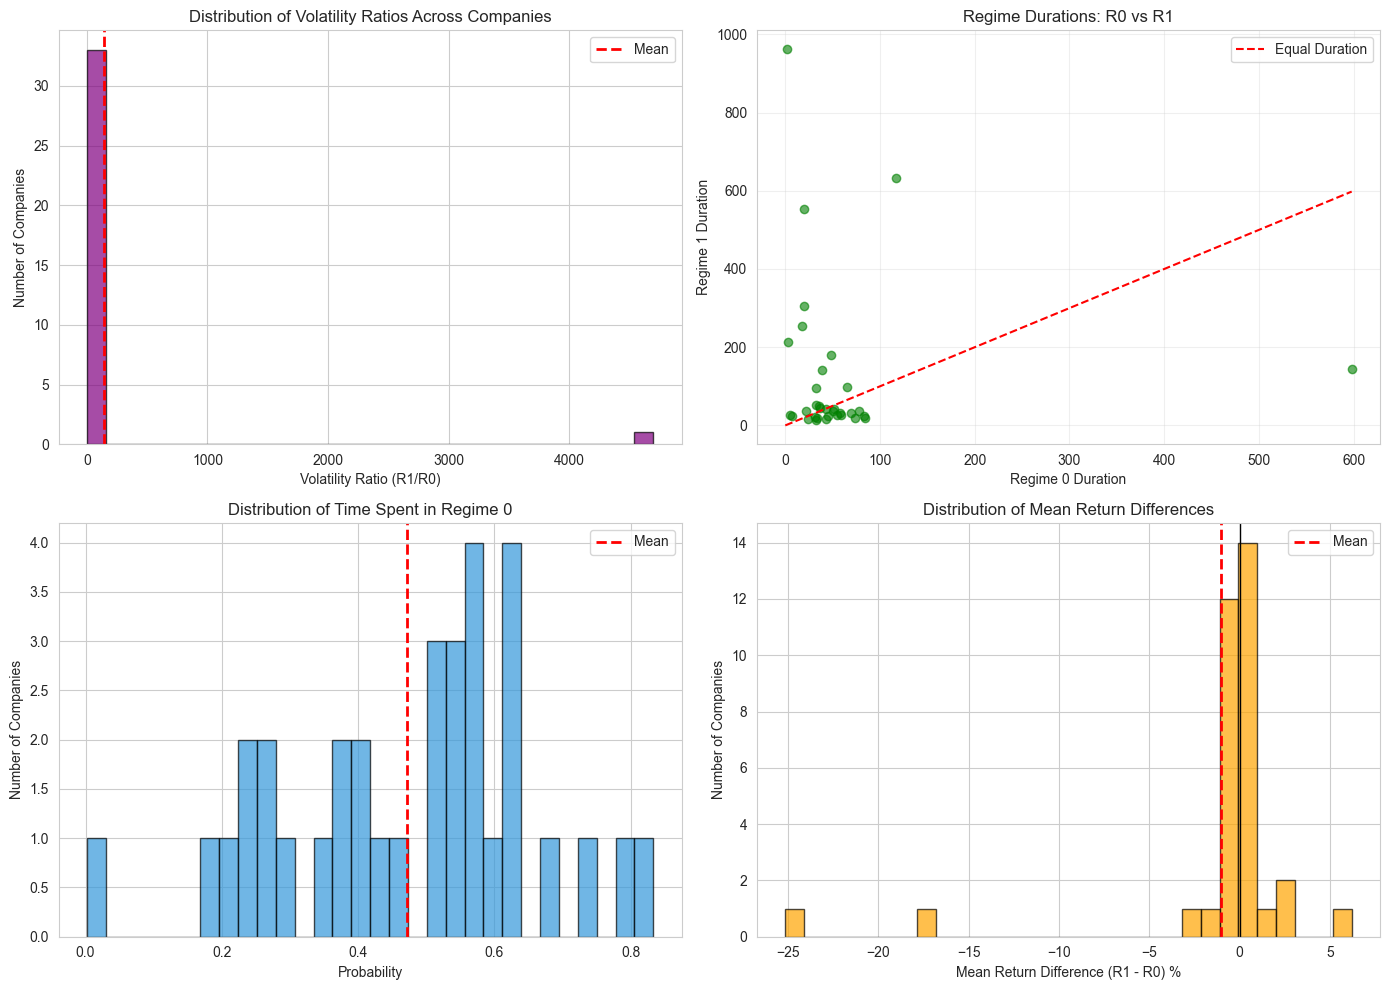

In [232]:
# Visualize company-level differences
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Volatility ratio across companies
axes[0, 0].hist(company_stats_rs['vol_ratio'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(company_stats_rs['vol_ratio'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Volatility Ratio (R1/R0)')
axes[0, 0].set_ylabel('Number of Companies')
axes[0, 0].set_title('Distribution of Volatility Ratios Across Companies')
axes[0, 0].legend()

# Duration comparison
axes[0, 1].scatter(company_stats_rs['duration_regime_0'], company_stats_rs['duration_regime_1'], alpha=0.6, color='green')
axes[0, 1].plot([0, company_stats_rs['duration_regime_0'].max()], [0, company_stats_rs['duration_regime_0'].max()], 'r--', label='Equal Duration')
axes[0, 1].set_xlabel('Regime 0 Duration')
axes[0, 1].set_ylabel('Regime 1 Duration')
axes[0, 1].set_title('Regime Durations: R0 vs R1')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Regime frequency
axes[1, 0].hist(company_stats_rs['steady_state_regime_0'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(company_stats_rs['steady_state_regime_0'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Probability')
axes[1, 0].set_ylabel('Number of Companies')
axes[1, 0].set_title('Distribution of Time Spent in Regime 0')
axes[1, 0].legend()

# Mean return difference
company_stats_rs['mean_diff'] = company_stats_rs['regime_1_mean'] - company_stats_rs['regime_0_mean']
axes[1, 1].hist(company_stats_rs['mean_diff']*100, bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(company_stats_rs['mean_diff'].mean()*100, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Mean Return Difference (R1 - R0) %')
axes[1, 1].set_ylabel('Number of Companies')
axes[1, 1].set_title('Distribution of Mean Return Differences')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [233]:
# Summary of key findings
print('='*80)
print('KEY FINDINGS SUMMARY')
print('='*80)

print('\n1. REGIME FREQUENCY:')
print(f"   - Average time in Regime 0 (RS): {rs_params['steady_state_regime_0'].mean():.2%}")
print(f"   - Average time in Regime 1 (RS): {rs_params['steady_state_regime_1'].mean():.2%}")
print(f"   - Average time in Regime 0 (MS-GARCH): {ms_garch['steady_state_regime_0'].mean():.2%}")
print(f"   - Average time in Regime 1 (MS-GARCH): {ms_garch['steady_state_regime_1'].mean():.2%}")

print('\n2. REGIME PERSISTENCE:')
print(f"   - Regime 0 expected duration (RS): {rs_params['duration_regime_0'].mean():.2f} periods")
print(f"   - Regime 1 expected duration (RS): {rs_params['duration_regime_1'].mean():.2f} periods")
print(f"   - Regime 0 expected duration (MS-GARCH): {ms_garch['duration_regime_0'].mean():.2f} periods")
print(f"   - Regime 1 expected duration (MS-GARCH): {ms_garch['duration_regime_1'].mean():.2f} periods")

print('\n3. PARAMETER DIFFERENCES:')
print(f"   - Mean return difference (RS): {(rs_params['regime_1_mean'].mean() - rs_params['regime_0_mean'].mean())*100:.4f}%")
print(f"   - Volatility ratio (RS): {(rs_params['regime_1_vol'].mean() / rs_params['regime_0_vol'].mean()):.2f}x")
print(f"   - Mean return difference (MS-GARCH): {(ms_garch['mu_1'].mean() - ms_garch['mu_0'].mean())*100:.4f}%")

print('\n4. CROSS-SECTIONAL VARIATION:')
print(f"   - Volatility ratio std dev: {company_stats_rs['vol_ratio'].std():.2f}")
print(f"   - Companies with higher vol in R1: {(company_stats_rs['vol_ratio'] > 1).sum()} / {len(company_stats_rs)}")
print(f"   - Companies with positive mean diff: {(company_stats_rs['mean_diff'] > 0).sum()} / {len(company_stats_rs)}")

print('\n' + '='*80)

KEY FINDINGS SUMMARY

1. REGIME FREQUENCY:
   - Average time in Regime 0 (RS): 47.18%
   - Average time in Regime 1 (RS): 52.82%
   - Average time in Regime 0 (MS-GARCH): 54.84%
   - Average time in Regime 1 (MS-GARCH): 45.16%

2. REGIME PERSISTENCE:
   - Regime 0 expected duration (RS): 58.98 periods
   - Regime 1 expected duration (RS): 125.25 periods
   - Regime 0 expected duration (MS-GARCH): 39.74 periods
   - Regime 1 expected duration (MS-GARCH): 32.06 periods

3. PARAMETER DIFFERENCES:
   - Mean return difference (RS): -1.0543%
   - Volatility ratio (RS): 2.76x
   - Mean return difference (MS-GARCH): -0.0399%

4. CROSS-SECTIONAL VARIATION:
   - Volatility ratio std dev: 804.66
   - Companies with higher vol in R1: 34 / 34
   - Companies with positive mean diff: 14 / 34



## 11. Leverage Group Analysis

Analyze regime switching and MS-GARCH parameters across different leverage groups.
This helps understand if regime dynamics differ between high-leverage and low-leverage firms.

In [234]:
# Load merged data to get leverage information
df_merged = pd.read_csv('data/output/merged_data_with_merton.csv')
df_merged['date'] = pd.to_datetime(df_merged['date'])

# Calculate leverage ratio
df_merged['leverage_ratio'] = df_merged['liabilities_total'] / (df_merged['liabilities_total'] + df_merged['mkt_cap'])

# Calculate average leverage for each firm
firm_leverage = df_merged.groupby('gvkey').agg({
    'leverage_ratio': 'mean',
    'company': 'first'
}).reset_index()

firm_leverage.columns = ['gvkey', 'avg_leverage', 'company']

# Create leverage terciles
firm_leverage['leverage_tercile'] = pd.qcut(
    firm_leverage['avg_leverage'], 
    q=3, 
    labels=['Low Leverage', 'Mid Leverage', 'High Leverage']
)

# Get tercile boundaries
tercile_boundaries = pd.qcut(firm_leverage['avg_leverage'], q=3, retbins=True)[1]

print("Leverage Group Definitions:")
print(f"Low Leverage:  < {tercile_boundaries[1]:.2%}")
print(f"Mid Leverage:  {tercile_boundaries[1]:.2%} - {tercile_boundaries[2]:.2%}")
print(f"High Leverage: > {tercile_boundaries[2]:.2%}")

# Create leverage mapping dictionary
leverage_group_map = firm_leverage.set_index('gvkey')['leverage_tercile'].to_dict()

# Add leverage groups to regime parameter dataframes
rs_params['leverage_tercile'] = rs_params['gvkey'].map(leverage_group_map)
ms_garch['leverage_tercile'] = ms_garch['gvkey'].map(leverage_group_map)

print(f"\n✓ Leverage groups assigned")
print(f"  Low Leverage: {(rs_params['leverage_tercile'] == 'Low Leverage').sum()} observations")
print(f"  Mid Leverage: {(rs_params['leverage_tercile'] == 'Mid Leverage').sum()} observations")
print(f"  High Leverage: {(rs_params['leverage_tercile'] == 'High Leverage').sum()} observations")

Leverage Group Definitions:
Low Leverage:  < 41.85%
Mid Leverage:  41.85% - 62.42%
High Leverage: > 62.42%

✓ Leverage groups assigned
  Low Leverage: 1711 observations
  Mid Leverage: 1569 observations
  High Leverage: 1562 observations


In [235]:
# Regime frequency by leverage group
print('='*80)
print('REGIME FREQUENCY BY LEVERAGE GROUP')
print('='*80)

for model_name, df, col_prefix in [('Regime Switching', rs_params, 'steady_state_regime_'), 
                                     ('MS-GARCH', ms_garch, 'steady_state_regime_')]:
    print(f"\n{model_name}:")
    print(f"{'-'*80}")
    
    for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
        group_data = df[df['leverage_tercile'] == leverage_group]
        regime_0_prob = group_data[f'{col_prefix}0'].mean()
        regime_1_prob = group_data[f'{col_prefix}1'].mean()
        
        print(f"\n  {leverage_group}:")
        print(f"    Regime 0: {regime_0_prob:.2%}")
        print(f"    Regime 1: {regime_1_prob:.2%}")

REGIME FREQUENCY BY LEVERAGE GROUP

Regime Switching:
--------------------------------------------------------------------------------

  Low Leverage:
    Regime 0: 45.70%
    Regime 1: 54.30%

  Mid Leverage:
    Regime 0: 50.32%
    Regime 1: 49.68%

  High Leverage:
    Regime 0: 45.67%
    Regime 1: 54.33%

MS-GARCH:
--------------------------------------------------------------------------------

  Low Leverage:
    Regime 0: 54.62%
    Regime 1: 45.38%

  Mid Leverage:
    Regime 0: 55.54%
    Regime 1: 44.46%

  High Leverage:
    Regime 0: 54.36%
    Regime 1: 45.64%


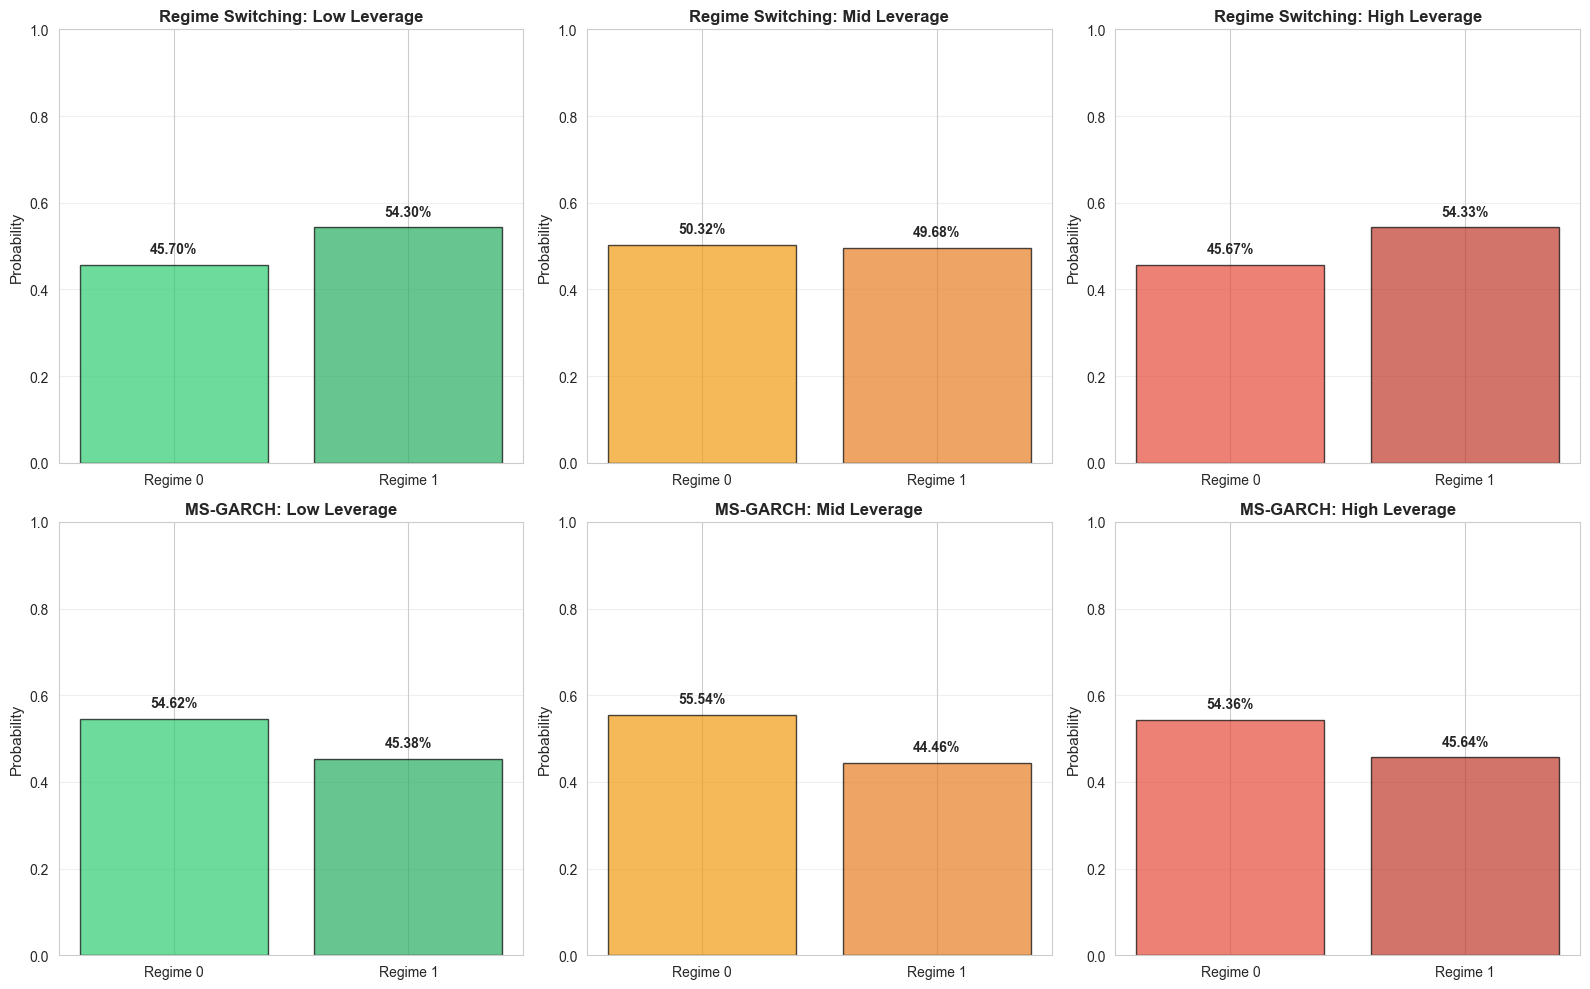

In [236]:
# Visualize regime frequency by leverage group
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
colors_r0 = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red
colors_r1 = ['#27ae60', '#e67e22', '#c0392b']  # Darker shades

# Regime Switching
for idx, leverage_group in enumerate(leverage_groups):
    ax = axes[0, idx]
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    
    regime_probs = [
        group_data['steady_state_regime_0'].mean(),
        group_data['steady_state_regime_1'].mean()
    ]
    
    bars = ax.bar(['Regime 0', 'Regime 1'], regime_probs, 
                   color=[colors_r0[idx], colors_r1[idx]], alpha=0.7, edgecolor='black')
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(f'Regime Switching: {leverage_group}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    
    for i, v in enumerate(regime_probs):
        ax.text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

# MS-GARCH
for idx, leverage_group in enumerate(leverage_groups):
    ax = axes[1, idx]
    group_data = ms_garch[ms_garch['leverage_tercile'] == leverage_group]
    
    regime_probs = [
        group_data['steady_state_regime_0'].mean(),
        group_data['steady_state_regime_1'].mean()
    ]
    
    bars = ax.bar(['Regime 0', 'Regime 1'], regime_probs, 
                   color=[colors_r0[idx], colors_r1[idx]], alpha=0.7, edgecolor='black')
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(f'MS-GARCH: {leverage_group}', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    
    for i, v in enumerate(regime_probs):
        ax.text(i, v + 0.02, f'{v:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [237]:
# Parameter comparison by leverage group - Regime Switching
print('='*80)
print('REGIME SWITCHING: PARAMETER COMPARISON BY LEVERAGE GROUP')
print('='*80)

rs_leverage_summary = []

for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    
    rs_leverage_summary.append({
        'Leverage Group': leverage_group,
        'Mean R0 (%)': group_data['regime_0_mean'].mean() * 100,
        'Mean R1 (%)': group_data['regime_1_mean'].mean() * 100,
        'Vol R0 (%)': group_data['regime_0_vol'].mean() * 100,
        'Vol R1 (%)': group_data['regime_1_vol'].mean() * 100,
        'Vol Ratio': group_data['regime_1_vol'].mean() / group_data['regime_0_vol'].mean(),
        'Duration R0': group_data['duration_regime_0'].mean(),
        'Duration R1': group_data['duration_regime_1'].mean(),
        'P(R0)': group_data['steady_state_regime_0'].mean(),
        'P(R1)': group_data['steady_state_regime_1'].mean()
    })

rs_leverage_df = pd.DataFrame(rs_leverage_summary)
display(rs_leverage_df.round(4))

REGIME SWITCHING: PARAMETER COMPARISON BY LEVERAGE GROUP


,Leverage Group,Mean R0 (%),Mean R1 (%),Vol R0 (%),Vol R1 (%),Vol Ratio,Duration R0,Duration R1,P(R0),P(R1)
0,Low Leverage,0.6290,0.2565,0.6854,1.7044,2.4867,36.1245,77.2933,0.4570,0.5430
1,Mid Leverage,0.1102,-0.0195,0.5449,1.3938,2.5578,37.1156,53.2349,0.5032,0.4968
2,High Leverage,-0.7211,-3.4510,0.6817,2.1973,3.2231,105.9738,250.1239,0.4567,0.5433


In [238]:
# Parameter comparison by leverage group - MS-GARCH (with robust unconditional vol)
print('='*80)
print('MS-GARCH: PARAMETER COMPARISON BY LEVERAGE GROUP')
print('='*80)

ms_leverage_summary = []

for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    group_data = ms_garch[ms_garch['leverage_tercile'] == leverage_group]
    n = len(group_data)
    
    ms_leverage_summary.append({
        'Leverage Group': leverage_group,
        'Mean R0 (%)': group_data['mu_0'].mean() * 100,
        'Mean R1 (%)': group_data['mu_1'].mean() * 100,
        'Omega R0': group_data['omega_0'].mean(),
        'Omega R1': group_data['omega_1'].mean(),
        'Alpha R0': group_data['alpha_0'].mean(),
        'Alpha R1': group_data['alpha_1'].mean(),
        'Beta R0': group_data['beta_0'].mean(),
        'Beta R1': group_data['beta_1'].mean(),
        'Persist R0': group_data['persist_0'].mean(),
        'Persist R1': group_data['persist_1'].mean(),
        'Uncond Vol R0 (%)': trimmed_mean(group_data['uncond_vol_0']) * 100,
        'Uncond Vol R1 (%)': trimmed_mean(group_data['uncond_vol_1']) * 100,
        '% near-IGARCH R1': (group_data['persist_1'] >= 0.999).sum() / n * 100,
        'Duration R0': group_data['duration_regime_0'].mean(),
        'Duration R1': group_data['duration_regime_1'].mean(),
        'P(R0)': group_data['steady_state_regime_0'].mean(),
        'P(R1)': group_data['steady_state_regime_1'].mean()
    })

ms_leverage_df = pd.DataFrame(ms_leverage_summary)
display(ms_leverage_df.round(6))

MS-GARCH: PARAMETER COMPARISON BY LEVERAGE GROUP


,Leverage Group,Mean R0 (%),Mean R1 (%),Omega R0,Omega R1,Alpha R0,Alpha R1,Beta R0,Beta R1,Persist R0,Persist R1,Uncond Vol R0 (%),Uncond Vol R1 (%),% near-IGARCH R1,Duration R0,Duration R1,P(R0),P(R1)
0,Low Leverage,-0.006134,-0.100472,0.000013,0.000094,0.049942,0.095751,0.782710,0.778975,0.832651,0.874726,0.696524,2.829979,0.0,31.773824,27.665052,0.546202,0.453798
1,Mid Leverage,-0.034052,-0.042340,0.000010,0.000064,0.049580,0.120223,0.782509,0.733339,0.832088,0.853562,0.545217,1.808470,0.0,36.292811,30.799953,0.555438,0.444562
2,High Leverage,0.018393,0.006483,0.000041,0.000210,0.075800,0.125755,0.739336,0.693612,0.815137,0.819367,0.379405,1.574763,0.0,51.925760,38.151682,0.543644,0.456356


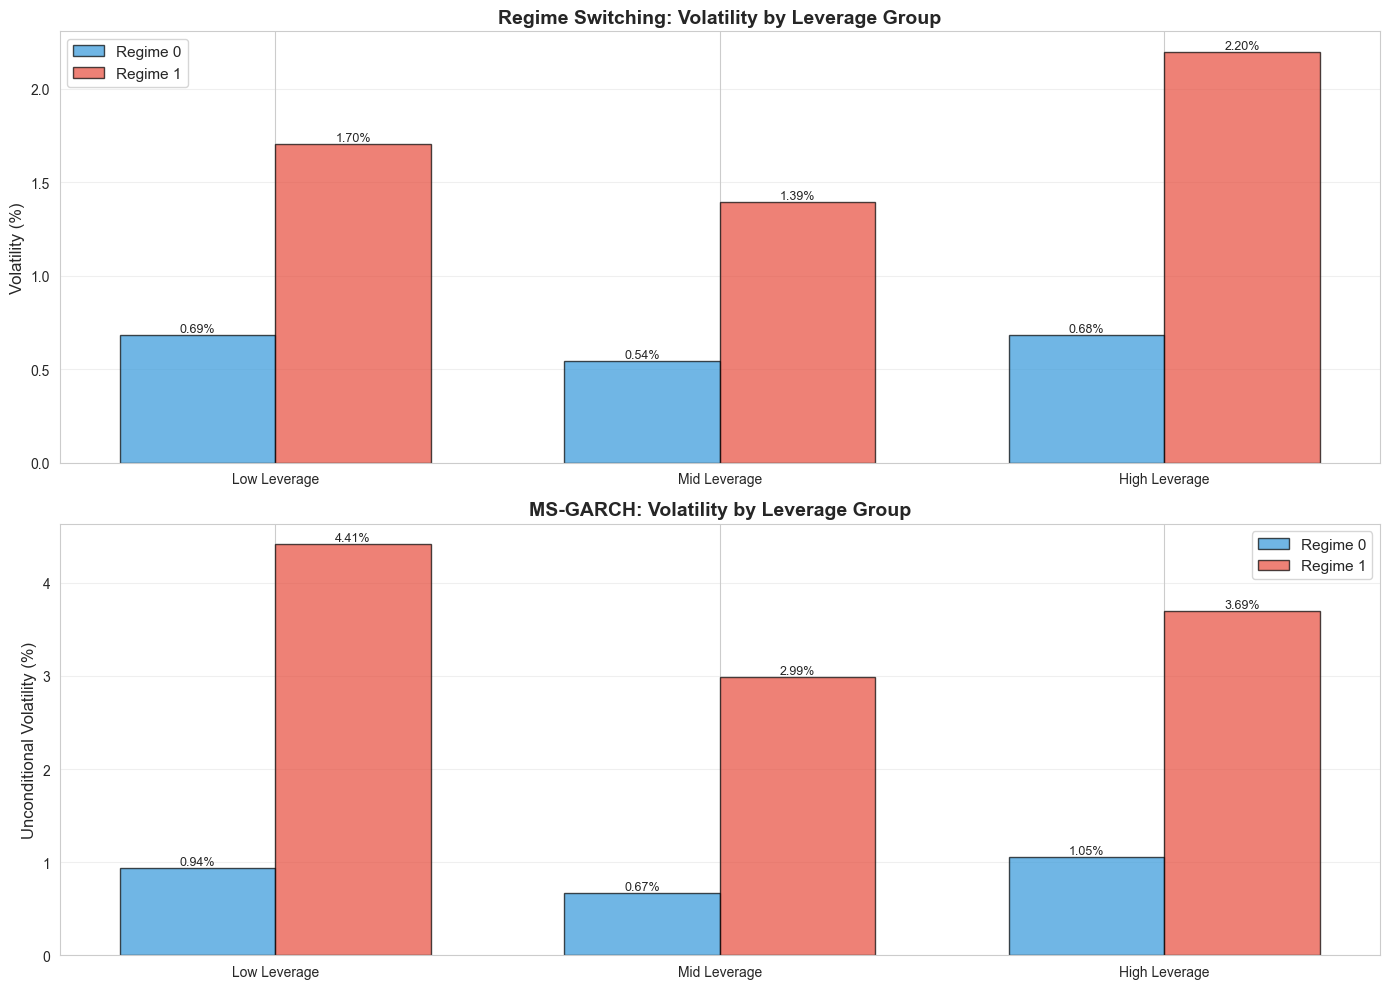

In [239]:
# Visualize volatility by leverage group
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

# Regime Switching
ax = axes[0]
x = np.arange(len(leverage_groups))
width = 0.35

r0_vols = [rs_params[rs_params['leverage_tercile'] == lg]['regime_0_vol'].mean() * 100 
           for lg in leverage_groups]
r1_vols = [rs_params[rs_params['leverage_tercile'] == lg]['regime_1_vol'].mean() * 100 
           for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_vols, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_vols, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Volatility (%)', fontsize=12)
ax.set_title('Regime Switching: Volatility by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

# MS-GARCH
ax = axes[1]
r0_vols_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['uncond_vol_0'].mean() * 100 
              for lg in leverage_groups]
r1_vols_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['uncond_vol_1'].mean() * 100 
              for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_vols_ms, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_vols_ms, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Unconditional Volatility (%)', fontsize=12)
ax.set_title('MS-GARCH: Volatility by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

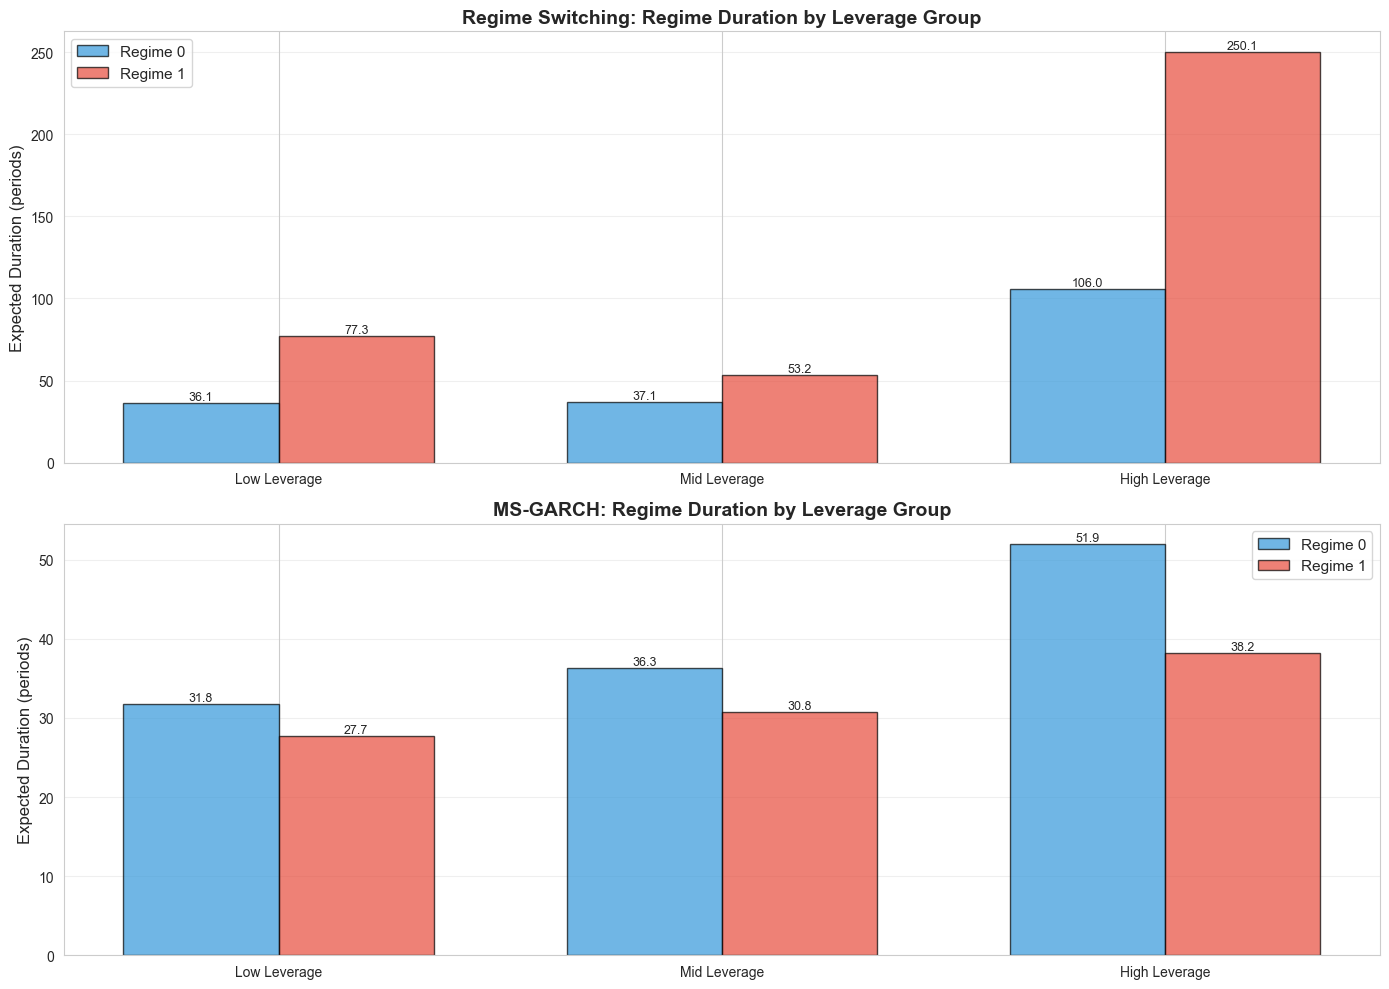

In [240]:
# Visualize regime duration by leverage group
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
x = np.arange(len(leverage_groups))
width = 0.35

# Regime Switching
ax = axes[0]
r0_durations = [rs_params[rs_params['leverage_tercile'] == lg]['duration_regime_0'].mean() 
                for lg in leverage_groups]
r1_durations = [rs_params[rs_params['leverage_tercile'] == lg]['duration_regime_1'].mean() 
                for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_durations, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_durations, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Expected Duration (periods)', fontsize=12)
ax.set_title('Regime Switching: Regime Duration by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# MS-GARCH
ax = axes[1]
r0_durations_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['duration_regime_0'].mean() 
                   for lg in leverage_groups]
r1_durations_ms = [ms_garch[ms_garch['leverage_tercile'] == lg]['duration_regime_1'].mean() 
                   for lg in leverage_groups]

bars1 = ax.bar(x - width/2, r0_durations_ms, width, label='Regime 0', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x + width/2, r1_durations_ms, width, label='Regime 1', color='#e74c3c', alpha=0.7, edgecolor='black')

ax.set_ylabel('Expected Duration (periods)', fontsize=12)
ax.set_title('MS-GARCH: Regime Duration by Leverage Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(leverage_groups)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

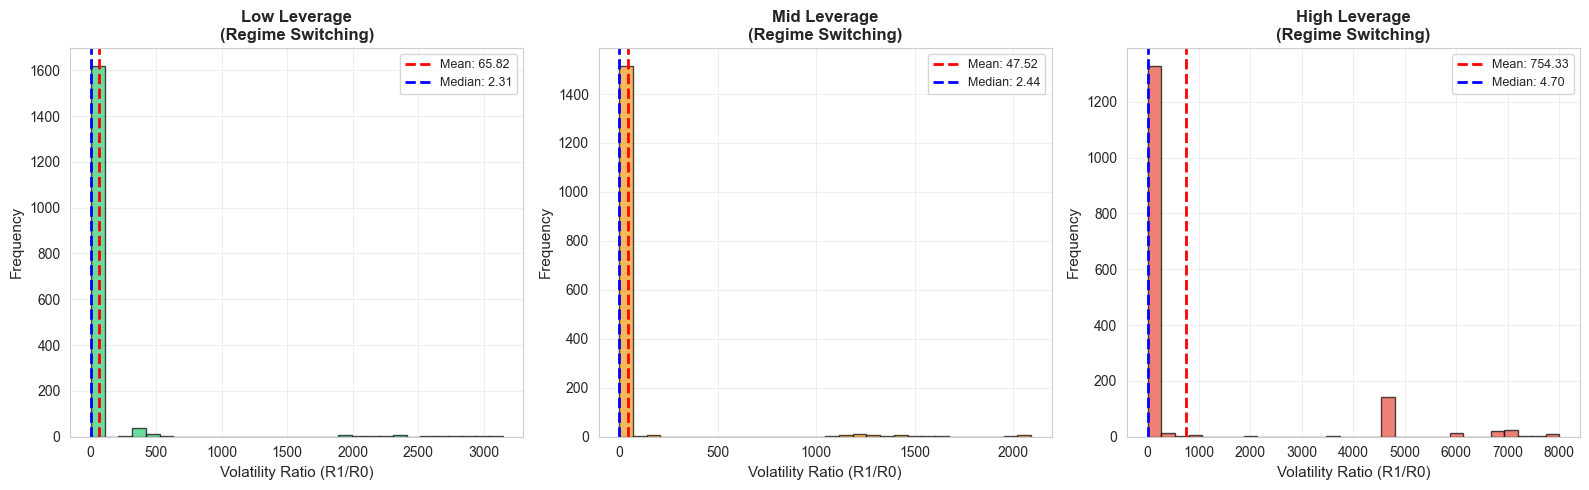

Volatility Ratio Summary by Leverage Group (Regime Switching):

Low Leverage:
  Mean:   65.8214
  Median: 2.3071
  Std:    355.6305
  Min:    1.0019
  Max:    3146.7660

Mid Leverage:
  Mean:   47.5196
  Median: 2.4419
  Std:    251.8153
  Min:    1.0038
  Max:    2090.5542

High Leverage:
  Mean:   754.3302
  Median: 4.6953
  Std:    1892.7280
  Min:    1.0069
  Max:    8003.5009


In [241]:
# Distribution of volatility ratios by leverage group
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

leverage_groups = ['Low Leverage', 'Mid Leverage', 'High Leverage']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

for idx, leverage_group in enumerate(leverage_groups):
    ax = axes[idx]
    
    # Get volatility ratio for this group (Regime Switching)
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    vol_ratios = group_data['regime_1_vol'] / group_data['regime_0_vol']
    
    ax.hist(vol_ratios, bins=30, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.axvline(vol_ratios.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {vol_ratios.mean():.2f}')
    ax.axvline(vol_ratios.median(), color='blue', linestyle='--', linewidth=2, 
               label=f'Median: {vol_ratios.median():.2f}')
    
    ax.set_xlabel('Volatility Ratio (R1/R0)', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{leverage_group}\n(Regime Switching)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print('Volatility Ratio Summary by Leverage Group (Regime Switching):')
print('='*80)
for leverage_group in leverage_groups:
    group_data = rs_params[rs_params['leverage_tercile'] == leverage_group]
    vol_ratios = group_data['regime_1_vol'] / group_data['regime_0_vol']
    
    print(f"\n{leverage_group}:")
    print(f"  Mean:   {vol_ratios.mean():.4f}")
    print(f"  Median: {vol_ratios.median():.4f}")
    print(f"  Std:    {vol_ratios.std():.4f}")
    print(f"  Min:    {vol_ratios.min():.4f}")
    print(f"  Max:    {vol_ratios.max():.4f}")

In [242]:
# Summary of leverage group findings
print('='*80)
print('LEVERAGE GROUP ANALYSIS - KEY FINDINGS')
print('='*80)

print('\n1. REGIME FREQUENCY BY LEVERAGE:')
for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    rs_group = rs_params[rs_params['leverage_tercile'] == leverage_group]
    ms_group = ms_garch[ms_garch['leverage_tercile'] == leverage_group]
    
    print(f"\n  {leverage_group}:")
    print(f"    RS - Regime 0: {rs_group['steady_state_regime_0'].mean():.2%}, Regime 1: {rs_group['steady_state_regime_1'].mean():.2%}")
    print(f"    MS - Regime 0: {ms_group['steady_state_regime_0'].mean():.2%}, Regime 1: {ms_group['steady_state_regime_1'].mean():.2%}")

print('\n2. VOLATILITY PATTERNS:')
for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    rs_group = rs_params[rs_params['leverage_tercile'] == leverage_group]
    vol_ratio = rs_group['regime_1_vol'].mean() / rs_group['regime_0_vol'].mean()
    
    print(f"\n  {leverage_group}:")
    print(f"    Regime 0 Vol: {rs_group['regime_0_vol'].mean()*100:.2f}%")
    print(f"    Regime 1 Vol: {rs_group['regime_1_vol'].mean()*100:.2f}%")
    print(f"    Volatility Ratio: {vol_ratio:.2f}x")

print('\n3. REGIME PERSISTENCE:')
for leverage_group in ['Low Leverage', 'Mid Leverage', 'High Leverage']:
    rs_group = rs_params[rs_params['leverage_tercile'] == leverage_group]
    
    print(f"\n  {leverage_group}:")
    print(f"    Regime 0 Duration: {rs_group['duration_regime_0'].mean():.1f} periods")
    print(f"    Regime 1 Duration: {rs_group['duration_regime_1'].mean():.1f} periods")

print('\n4. INTERPRETATION:')
print('  - High leverage firms may show different regime dynamics')
print('  - Volatility patterns may vary by capital structure')
print('  - Regime persistence could differ across leverage groups')
print('  - Consider leverage when interpreting regime-switching behavior')

print('\n' + '='*80)

LEVERAGE GROUP ANALYSIS - KEY FINDINGS

1. REGIME FREQUENCY BY LEVERAGE:

  Low Leverage:
    RS - Regime 0: 45.70%, Regime 1: 54.30%
    MS - Regime 0: 54.62%, Regime 1: 45.38%

  Mid Leverage:
    RS - Regime 0: 50.32%, Regime 1: 49.68%
    MS - Regime 0: 55.54%, Regime 1: 44.46%

  High Leverage:
    RS - Regime 0: 45.67%, Regime 1: 54.33%
    MS - Regime 0: 54.36%, Regime 1: 45.64%

2. VOLATILITY PATTERNS:

  Low Leverage:
    Regime 0 Vol: 0.69%
    Regime 1 Vol: 1.70%
    Volatility Ratio: 2.49x

  Mid Leverage:
    Regime 0 Vol: 0.54%
    Regime 1 Vol: 1.39%
    Volatility Ratio: 2.56x

  High Leverage:
    Regime 0 Vol: 0.68%
    Regime 1 Vol: 2.20%
    Volatility Ratio: 3.22x

3. REGIME PERSISTENCE:

  Low Leverage:
    Regime 0 Duration: 36.1 periods
    Regime 1 Duration: 77.3 periods

  Mid Leverage:
    Regime 0 Duration: 37.1 periods
    Regime 1 Duration: 53.2 periods

  High Leverage:
    Regime 0 Duration: 106.0 periods
    Regime 1 Duration: 250.1 periods

4. INTERPRE

## 12. MS-GARCH: GARCH Dynamics per Regime

Deep-dive into the regime-specific GARCH(1,1) parameters.

We extract **derived metrics** (persistence, unconditional volatility, half-life of
shocks, stationarity) and produce four diagnostic plots:
1. Parameter comparison bar chart
2. Persistence & unconditional volatility
3. News Impact Curves
4. Volatility Impulse Response

MS-GARCH  —  DERIVED PER-REGIME METRICS
          omega    alpha     beta        nu  persistence  stationary  uncond_vol  half_life   p_stay  steady_state  expected_duration
regime                                                                                                                               
0      0.000021 0.058166 0.768652 22.232518     0.826819        True    0.005429   3.644886 0.839014      0.542463           6.211717
1      0.000122 0.113360 0.736649  6.066301     0.850010        True    0.020761   4.265325 0.809132      0.457537           5.239232



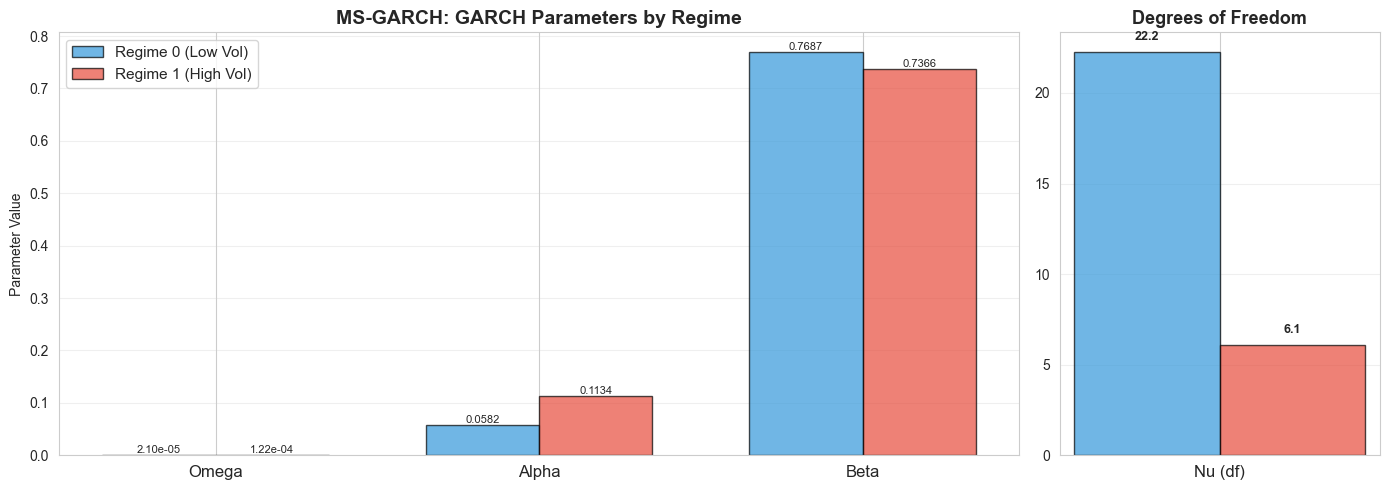

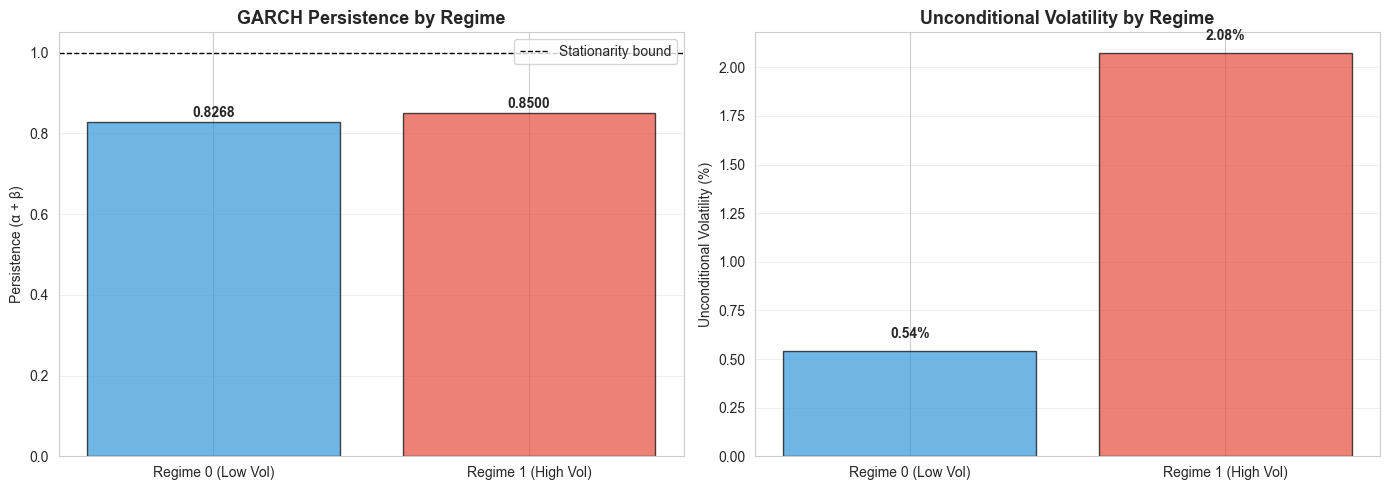

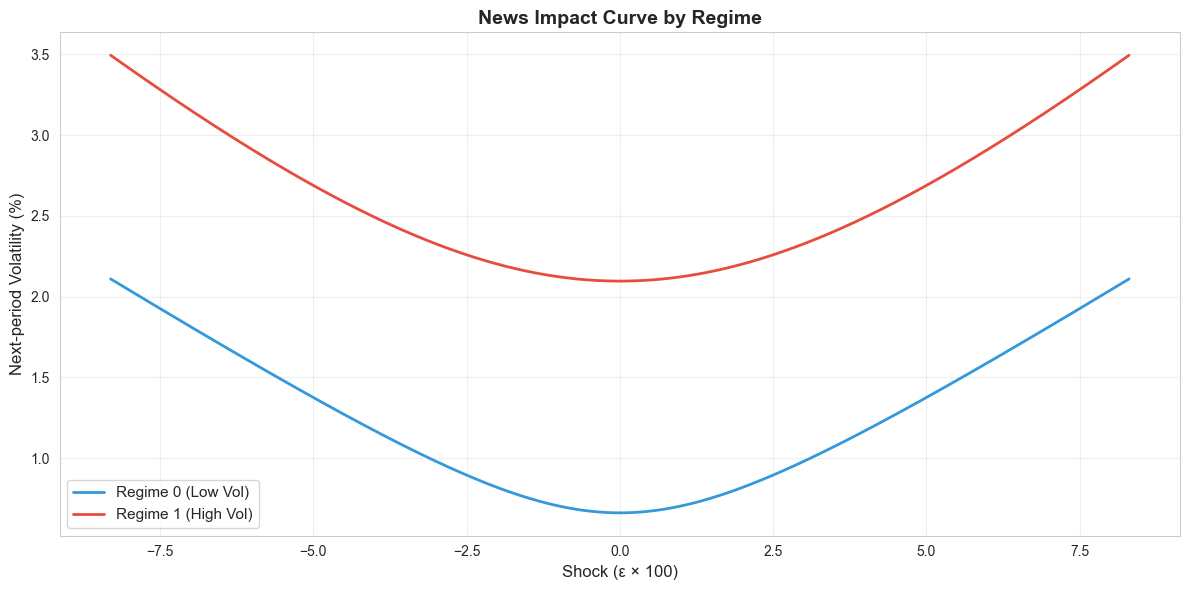

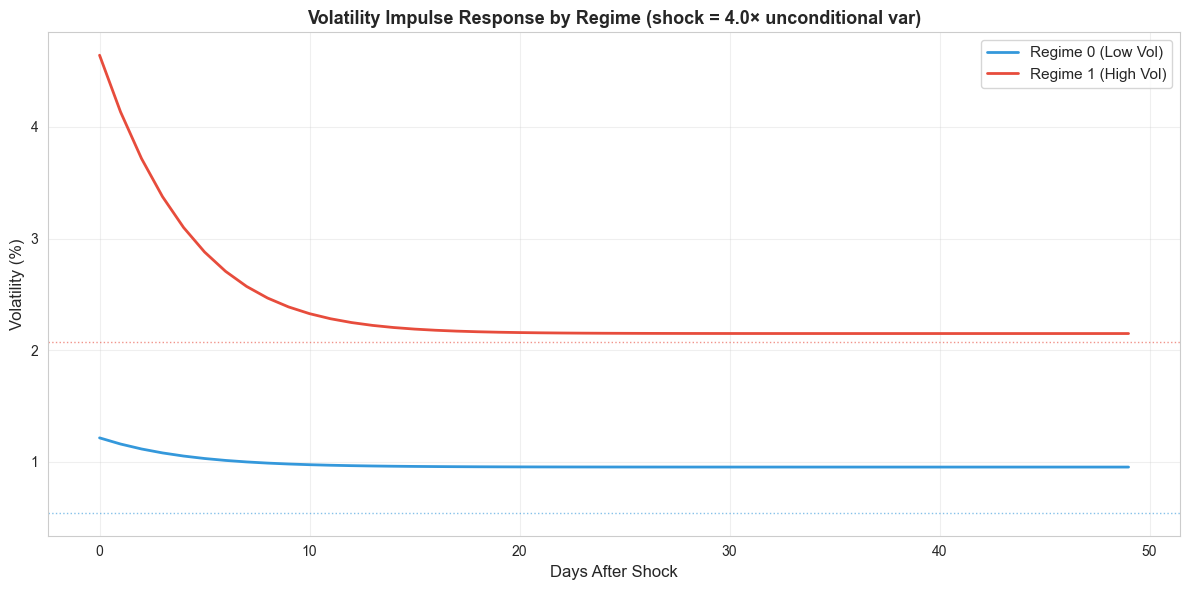

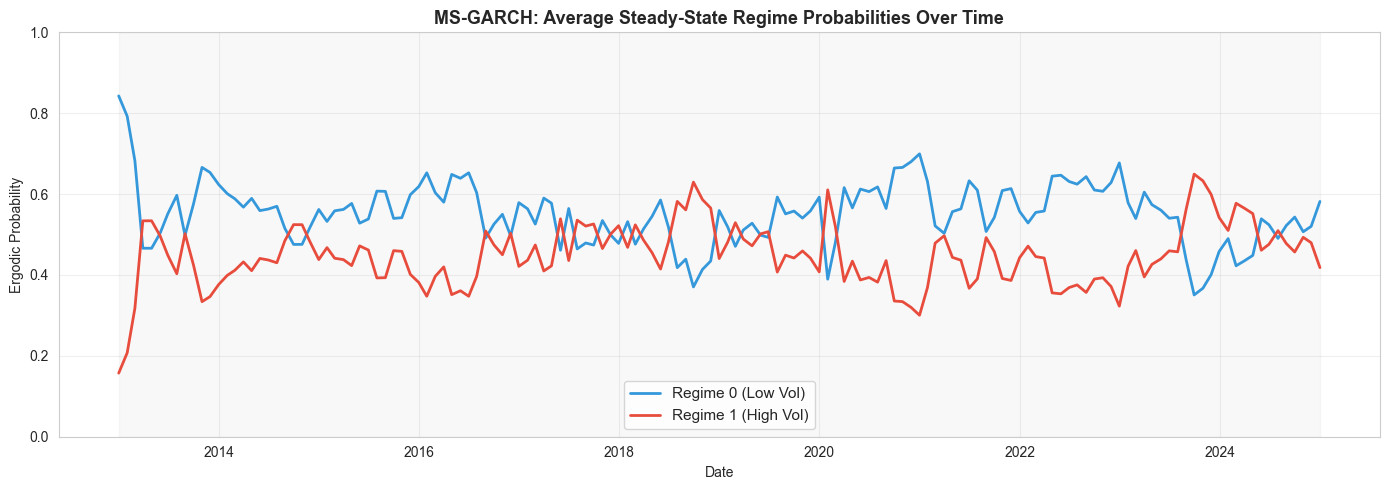

In [243]:
import sys, importlib
sys.path.insert(0, '.')

# Import (or reload) the analysis module
import src.analysis.regime_analysis as ra
importlib.reload(ra)

# Run the full analysis — prints metrics table + generates all plots
ms_garch_metrics = ra.run_ms_garch_analysis(ms_garch, verbose=True)

## 13. MS-GARCH: Alpha, Beta & Persistence Over Time

**Plot 1** — cross-sectional **median** of α, β and α+β for each regime over time (6 lines).  
**Plot 2** — same three metrics for a **single firm** (uses the same `sample_gvkey` selected in Section 8).

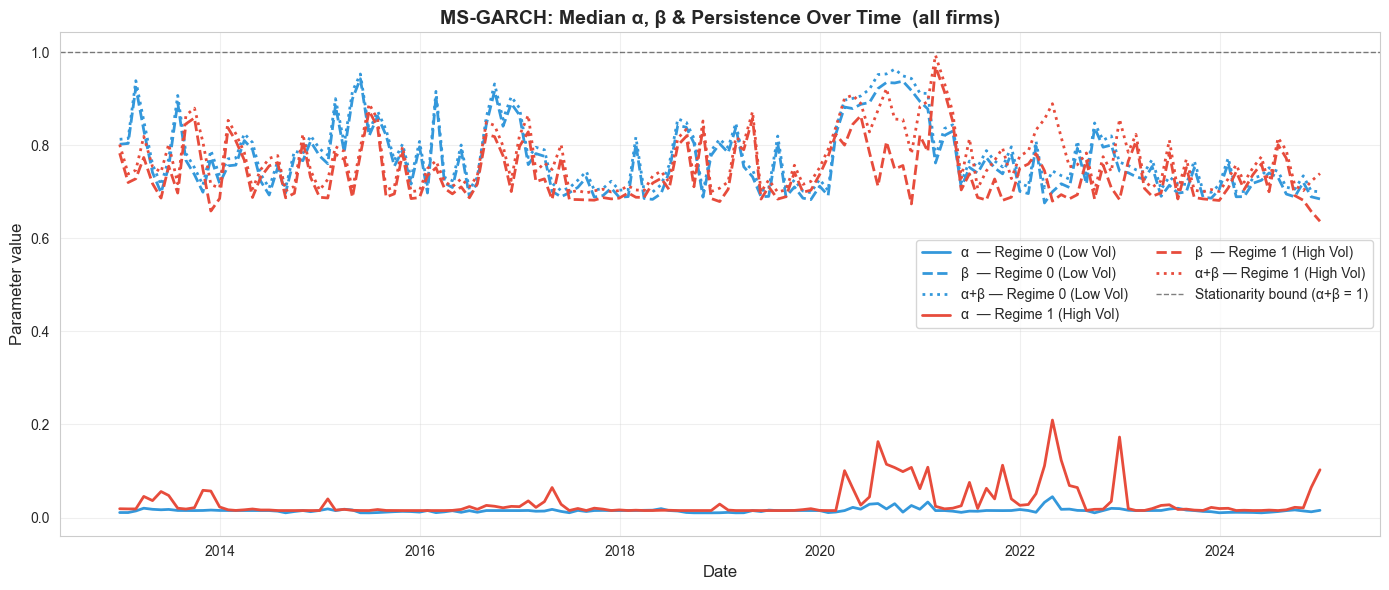

In [244]:
# ── Plot 1: Cross-sectional median α, β, persistence per regime — one graph ──

ts_median = ms_garch.groupby('date').agg(
    alpha_0=('alpha_0', 'median'),
    alpha_1=('alpha_1', 'median'),
    beta_0=('beta_0',  'median'),
    beta_1=('beta_1',  'median'),
)
ts_median['persistence_0'] = ts_median['alpha_0'] + ts_median['beta_0']
ts_median['persistence_1'] = ts_median['alpha_1'] + ts_median['beta_1']

fig, ax = plt.subplots(figsize=(14, 6))

# Regime 0 lines (blue shades)
ax.plot(ts_median.index, ts_median['alpha_0'],       color='#3498db', linewidth=2, linestyle='-',  label='α  — Regime 0 (Low Vol)')
ax.plot(ts_median.index, ts_median['beta_0'],        color='#3498db', linewidth=2, linestyle='--', label='β  — Regime 0 (Low Vol)')
ax.plot(ts_median.index, ts_median['persistence_0'], color='#3498db', linewidth=2, linestyle=':',  label='α+β — Regime 0 (Low Vol)')

# Regime 1 lines (red shades)
ax.plot(ts_median.index, ts_median['alpha_1'],       color='#e74c3c', linewidth=2, linestyle='-',  label='α  — Regime 1 (High Vol)')
ax.plot(ts_median.index, ts_median['beta_1'],        color='#e74c3c', linewidth=2, linestyle='--', label='β  — Regime 1 (High Vol)')
ax.plot(ts_median.index, ts_median['persistence_1'], color='#e74c3c', linewidth=2, linestyle=':',  label='α+β — Regime 1 (High Vol)')

ax.axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Stationarity bound (α+β = 1)')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Parameter value', fontsize=12)
ax.set_title('MS-GARCH: Median α, β & Persistence Over Time  (all firms)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [245]:
# ── Firm selector ─────────────────────────────────────────────────────────────
# Change `selected_gvkey` to any gvkey present in ms_garch, then re-run this
# cell and the plot cell below.

available_gvkeys = sorted(ms_garch['gvkey'].unique())
print(f"Total firms available: {len(available_gvkeys)}")
print(f"First 20 gvkeys: {available_gvkeys[:20]}")

# ── Set your firm here ────────────────────────────────────────────────────────
selected_gvkey = 241456   # <-- change this value

# Validate
if selected_gvkey not in available_gvkeys:
    raise ValueError(f"gvkey {selected_gvkey} not found. Choose from available_gvkeys list above.")

firm_ts = (ms_garch[ms_garch['gvkey'] == selected_gvkey]
           [['date', 'alpha_0', 'beta_0', 'alpha_1', 'beta_1']]
           .sort_values('date')
           .copy())
firm_ts['persistence_0'] = firm_ts['alpha_0'] + firm_ts['beta_0']
firm_ts['persistence_1'] = firm_ts['alpha_1'] + firm_ts['beta_1']

n_obs = len(firm_ts)
date_range = f"{firm_ts['date'].min().strftime('%Y-%m')} → {firm_ts['date'].max().strftime('%Y-%m')}"
print(f"\nSelected firm  : gvkey = {selected_gvkey}")
print(f"Observations   : {n_obs} windows")
print(f"Date range     : {date_range}")
print(f"\nParameter summary:")
print(firm_ts[['alpha_0','beta_0','persistence_0','alpha_1','beta_1','persistence_1']].describe().round(4))

Total firms available: 34
First 20 gvkeys: [np.int64(14447), np.int64(15532), np.int64(15549), np.int64(15617), np.int64(15677), np.int64(15724), np.int64(16348), np.int64(17436), np.int64(17452), np.int64(19349), np.int64(23667), np.int64(23671), np.int64(24625), np.int64(61616), np.int64(63120), np.int64(100022), np.int64(100080), np.int64(100581), np.int64(100957), np.int64(101202)]

Selected firm  : gvkey = 241456
Observations   : 143 windows
Date range     : 2013-02 → 2024-12

Parameter summary:
        alpha_0    beta_0  persistence_0   alpha_1    beta_1  persistence_1
count  143.0000  143.0000       143.0000  143.0000  143.0000       143.0000
mean     0.0362    0.8103         0.8465    0.0983    0.7547         0.8530
std      0.0691    0.1651         0.1290    0.1591    0.2067         0.1282
min      0.0100    0.3000         0.6000    0.0100    0.3000         0.6000
25%      0.0100    0.6887         0.7018    0.0141    0.6642         0.6997
50%      0.0101    0.8564         0.88

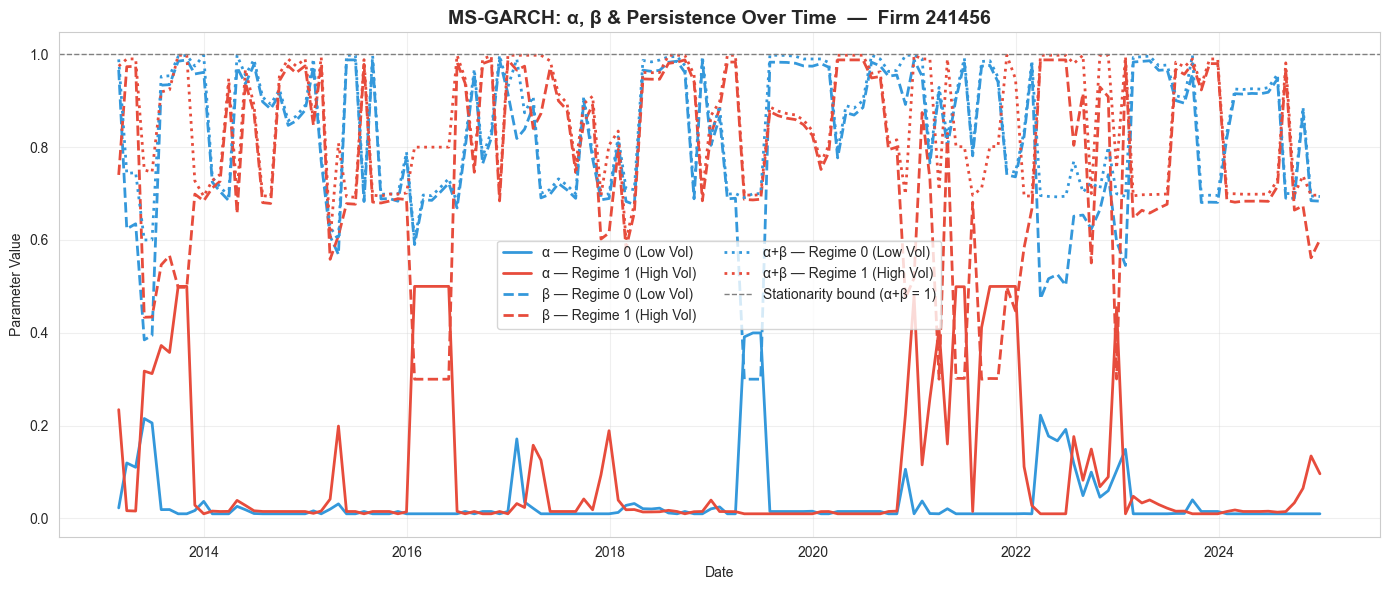

In [246]:
# ── Plot: α, β, persistence per regime for selected firm ─────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(firm_ts['date'], firm_ts['alpha_0'],       color='#3498db', linestyle='-',  linewidth=2, label='α — Regime 0 (Low Vol)')
ax.plot(firm_ts['date'], firm_ts['alpha_1'],       color='#e74c3c', linestyle='-',  linewidth=2, label='α — Regime 1 (High Vol)')
ax.plot(firm_ts['date'], firm_ts['beta_0'],        color='#3498db', linestyle='--', linewidth=2, label='β — Regime 0 (Low Vol)')
ax.plot(firm_ts['date'], firm_ts['beta_1'],        color='#e74c3c', linestyle='--', linewidth=2, label='β — Regime 1 (High Vol)')
ax.plot(firm_ts['date'], firm_ts['persistence_0'], color='#3498db', linestyle=':',  linewidth=2, label='α+β — Regime 0 (Low Vol)')
ax.plot(firm_ts['date'], firm_ts['persistence_1'], color='#e74c3c', linestyle=':',  linewidth=2, label='α+β — Regime 1 (High Vol)')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Stationarity bound (α+β = 1)')

ax.set_xlabel('Date')
ax.set_ylabel('Parameter Value')
ax.set_title(f'MS-GARCH: α, β & Persistence Over Time  —  Firm {selected_gvkey}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()